# 🚗 Vehicle Loan Default — EDA
**Framework:** 5 Business Themes × Domain-First Questions  
**Data:** `../data/train.csv`  (233,154 สัญญา)

## ⚙️ Setup

In [99]:
import warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

DATA_PATH = "../data/train.csv"
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.upper()

# ── parse age-string columns (e.g. "2yrs 3mon") → total months
def parse_months(s):
    if pd.isna(s): return np.nan
    y = re.search(r"(\d+)yrs", str(s))
    m = re.search(r"(\d+)mon", str(s))
    return int(y.group(1))*12 + int(m.group(1)) if y else np.nan

df["AVERAGE_ACCT_AGE_MON"]    = df["AVERAGE_ACCT_AGE"].apply(parse_months)
df["CREDIT_HISTORY_LEN_MON"]  = df["CREDIT_HISTORY_LENGTH"].apply(parse_months)

# ── compute age
df["DATE_OF_BIRTH"]  = pd.to_datetime(df["DATE_OF_BIRTH"],  dayfirst=True, errors="coerce")
df["DISBURSAL_DATE"] = pd.to_datetime(df["DISBURSAL_DATE"], dayfirst=True, errors="coerce")
df["AGE_AT_DISBURSAL"] = (df["DISBURSAL_DATE"] - df["DATE_OF_BIRTH"]).dt.days // 365

print(f"Shape: {df.shape}")
print(f"Default rate: {df['LOAN_DEFAULT'].mean():.2%}")
df.head(2)

Shape: (233154, 44)
Default rate: 21.71%


,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,...,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT,AVERAGE_ACCT_AGE_MON,CREDIT_HISTORY_LEN_MON,AGE_AT_DISBURSAL
0,420825,50578,58400,89.55,67,22807,45,1441,1984-01-01,Salaried,...,0,0,0,0yrs 0mon,0yrs 0mon,0,0,0,0,34
1,537409,47145,65550,73.23,67,22807,45,1502,1985-07-31,Self employed,...,0,0,1,1yrs 11mon,1yrs 11mon,0,1,23,23,33


## 🔍Data Overview

In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 41 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   UNIQUEID                             233154 non-null  int64  
 1   DISBURSED_AMOUNT                     233154 non-null  int64  
 2   ASSET_COST                           233154 non-null  int64  
 3   LTV                                  233154 non-null  float64
 4   BRANCH_ID                            233154 non-null  int64  
 5   SUPPLIER_ID                          233154 non-null  int64  
 6   MANUFACTURER_ID                      233154 non-null  int64  
 7   CURRENT_PINCODE_ID                   233154 non-null  int64  
 8   DATE_OF_BIRTH                        233154 non-null  str    
 9   EMPLOYMENT_TYPE                      225493 non-null  str    
 10  DISBURSAL_DATE                       233154 non-null  str    
 11  STATE_ID                

In [77]:
df.describe()

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,STATE_ID,EMPLOYEE_CODE_ID,...,SEC_OVERDUE_ACCTS,SEC_CURRENT_BALANCE,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,NO_OF_INQUIRIES,LOAN_DEFAULT
count,233154.000000,233154.000000,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,...,233154.000000,2.331540e+05,2.331540e+05,2.331540e+05,2.331540e+05,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000
mean,535917.573376,54356.993528,7.586507e+04,74.746530,72.936094,19638.635035,69.028054,3396.880247,7.262243,1549.477148,...,0.007244,5.427793e+03,7.295923e+03,7.179998e+03,1.310548e+04,3.232684e+02,0.381833,0.097481,0.206615,0.217071
std,68315.693711,12971.314171,1.894478e+04,11.456636,69.834995,3491.949566,22.141304,2238.147502,4.482230,975.261278,...,0.111079,1.702370e+05,1.831560e+05,1.825925e+05,1.513679e+05,1.555369e+04,0.955107,0.384439,0.706498,0.412252
min,417428.000000,13320.000000,3.700000e+04,10.030000,1.000000,10524.000000,45.000000,1.000000,1.000000,1.000000,...,0.000000,-5.746470e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,476786.250000,47145.000000,6.571700e+04,68.880000,14.000000,16535.000000,48.000000,1511.000000,4.000000,713.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
50%,535978.500000,53803.000000,7.094600e+04,76.800000,61.000000,20333.000000,86.000000,2970.000000,6.000000,1451.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000
75%,595039.750000,60413.000000,7.920175e+04,83.670000,130.000000,23000.000000,86.000000,5677.000000,10.000000,2362.000000,...,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.999000e+03,0.000000e+00,0.000000,0.000000,0.000000,0.000000
max,671084.000000,990572.000000,1.628992e+06,95.000000,261.000000,24803.000000,156.000000,7345.000000,22.000000,3795.000000,...,8.000000,3.603285e+07,3.000000e+07,3.000000e+07,2.564281e+07,4.170901e+06,35.000000,20.000000,36.000000,1.000000


In [83]:
# ============================================================
# 1. Shape & Target
# ============================================================
print(f"Shape     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target    : LOAN_DEFAULT  →  default rate = {df['LOAN_DEFAULT'].mean():.2%}")
df.head(3)


Shape     : 233,154 rows × 41 columns
Target    : LOAN_DEFAULT  →  default rate = 21.71%


,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,...,SEC_SANCTIONED_AMOUNT,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
0,420825,50578,58400,89.55,67,22807,45,1441,01-01-1984,Salaried,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0
1,537409,47145,65550,73.23,67,22807,45,1502,31-07-1985,Self employed,...,0,0,1991,0,0,1,1yrs 11mon,1yrs 11mon,0,1
2,417566,53278,61360,89.63,67,22807,45,1497,24-08-1985,Self employed,...,0,0,0,0,0,0,0yrs 0mon,0yrs 0mon,0,0


In [82]:
# ============================================================
# 2. Column Metadata
# ============================================================
meta = pd.DataFrame({
    "dtype"    : df.dtypes,
    "non_null" : df.notnull().sum(),
    "null"     : df.isnull().sum(),
    "null_%"   : (df.isnull().mean() * 100).round(2),
    "nunique"  : df.nunique(),
    "sample"   : df.apply(lambda c: c.dropna().iloc[0] if c.notna().any() else np.nan),
})
print("Column Metadata:")
display(meta)


Column Metadata:


,dtype,non_null,null,null_%,nunique,sample
UNIQUEID,int64,233154,0,0.00,233154,420825
DISBURSED_AMOUNT,int64,233154,0,0.00,24565,50578
ASSET_COST,int64,233154,0,0.00,46252,58400
LTV,float64,233154,0,0.00,6579,89.55
BRANCH_ID,int64,233154,0,0.00,82,67
SUPPLIER_ID,int64,233154,0,0.00,2953,22807
MANUFACTURER_ID,int64,233154,0,0.00,11,45
CURRENT_PINCODE_ID,int64,233154,0,0.00,6698,1441
DATE_OF_BIRTH,str,233154,0,0.00,15433,01-01-1984
EMPLOYMENT_TYPE,str,225493,7661,3.29,2,Salaried


In [81]:
# ============================================================
# 3. Numeric Summary (key stats)
# ============================================================
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c not in ("UNIQUEID", "LOAN_DEFAULT")]

stats = df[num_cols].describe(percentiles=[.25, .5, .75, .95]).T
stats["skew"] = df[num_cols].skew().round(2)
stats["kurt"] = df[num_cols].kurt().round(2)
print("Numeric Summary (excl. ID & target):")
display(stats.style.background_gradient(subset=["skew"], cmap="RdYlGn_r"))


Numeric Summary (excl. ID & target):


,count,mean,std,min,25%,50%,75%,95%,max,skew,kurt
DISBURSED_AMOUNT,233154.000000,54356.993528,12971.314171,13320.000000,47145.000000,53803.000000,60413.000000,74122.350000,990572.000000,4.490000,249.990000
ASSET_COST,233154.000000,75865.068144,18944.781289,37000.000000,65717.000000,70946.000000,79201.750000,109680.000000,1628992.000000,6.130000,291.490000
LTV,233154.000000,74.746530,11.456636,10.030000,68.880000,76.800000,83.670000,89.380000,95.000000,-1.080000,1.290000
BRANCH_ID,233154.000000,72.936094,69.834995,1.000000,14.000000,61.000000,130.000000,249.000000,261.000000,1.030000,0.300000
SUPPLIER_ID,233154.000000,19638.635035,3491.949566,10524.000000,16535.000000,20333.000000,23000.000000,24122.000000,24803.000000,-0.170000,-1.480000
MANUFACTURER_ID,233154.000000,69.028054,22.141304,45.000000,48.000000,86.000000,86.000000,86.000000,156.000000,0.390000,-0.720000
CURRENT_PINCODE_ID,233154.000000,3396.880247,2238.147502,1.000000,1511.000000,2970.000000,5677.000000,6942.000000,7345.000000,0.280000,-1.290000
STATE_ID,233154.000000,7.262243,4.482230,1.000000,4.000000,6.000000,10.000000,16.000000,22.000000,0.820000,-0.330000
EMPLOYEE_CODE_ID,233154.000000,1549.477148,975.261278,1.000000,713.000000,1451.000000,2362.000000,3186.000000,3795.000000,0.240000,-1.050000
MOBILENO_AVL_FLAG,233154.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000


Missing Values:


,missing_count,missing_%
EMPLOYMENT_TYPE,7661,3.29


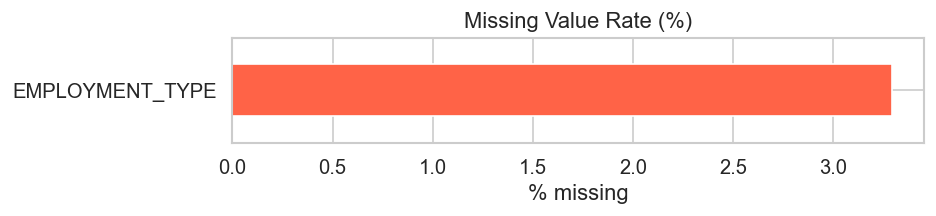


Duplicates: 0


In [84]:
# ============================================================
# 4. Missing Values
# ============================================================
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)

if miss.empty:
    print("✅ No missing values")
else:
    miss_df = pd.DataFrame({
        "missing_count" : miss,
        "missing_%"     : (miss / len(df) * 100).round(2),
    })
    print("Missing Values:")
    display(miss_df)

    # visualise
    fig, ax = plt.subplots(figsize=(8, max(2, len(miss) * 0.5)))
    miss_df["missing_%"].sort_values().plot(kind="barh", ax=ax, color="tomato")
    ax.set_title("Missing Value Rate (%)")
    ax.set_xlabel("% missing")
    plt.tight_layout(); plt.show()

print(f"\nDuplicates: {df.duplicated().sum():,}")


In [56]:
df.isnull().sum().sort_values(ascending=False)

EMPLOYMENT_TYPE                        7661
UNIQUEID                                  0
PRIMARY_INSTAL_AMT                        0
PRI_SANCTIONED_AMOUNT                     0
PRI_DISBURSED_AMOUNT                      0
SEC_NO_OF_ACCTS                           0
SEC_ACTIVE_ACCTS                          0
SEC_OVERDUE_ACCTS                         0
SEC_CURRENT_BALANCE                       0
SEC_SANCTIONED_AMOUNT                     0
SEC_DISBURSED_AMOUNT                      0
SEC_INSTAL_AMT                            0
PRI_OVERDUE_ACCTS                         0
NEW_ACCTS_IN_LAST_SIX_MONTHS              0
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS       0
AVERAGE_ACCT_AGE                          0
CREDIT_HISTORY_LENGTH                     0
NO_OF_INQUIRIES                           0
LOAN_DEFAULT                              0
AVERAGE_ACCT_AGE_MON                      0
CREDIT_HISTORY_LEN_MON                    0
PRI_CURRENT_BALANCE                       0
PRI_ACTIVE_ACCTS                

In [85]:
# missing rate
print(f"Missing: {df['EMPLOYMENT_TYPE'].isnull().mean():.2%}")

# Default rate ของ missing vs non-missing
df['emp_missing'] = df['EMPLOYMENT_TYPE'].isnull().astype(int)
df.groupby('emp_missing')['LOAN_DEFAULT'].mean()

Missing: 3.29%


emp_missing
0    0.217155
1    0.214593
Name: LOAN_DEFAULT, dtype: float64

In [59]:
# ดูว่า missing เยอะในกลุ่ม Employment ไหน
df[df['EMPLOYMENT_TYPE'].notnull()]['EMPLOYMENT_TYPE'].value_counts(normalize=True)

EMPLOYMENT_TYPE
Self employed    0.566026
Salaried         0.433974
Name: proportion, dtype: float64

In [60]:
df['EMPLOYMENT_TYPE'] = df['EMPLOYMENT_TYPE'].fillna('Unknown')

In [61]:
df.groupby('EMPLOYMENT_TYPE')['LOAN_DEFAULT'].mean().sort_values(ascending=False)

EMPLOYMENT_TYPE
Self employed    0.227657
Unknown          0.214593
Salaried         0.203458
Name: LOAN_DEFAULT, dtype: float64

In [66]:
# Numerical vs Target
df.groupby('LOAN_DEFAULT')['LTV'].describe()

,count,mean,std,min,25%,50%,75%,max
LOAN_DEFAULT,,,,,,,,
0,182543.0,74.154093,11.681455,10.03,68.020,76.00,83.16,95.0
1,50611.0,76.883322,10.327771,15.30,72.055,79.06,84.68,95.0


In [65]:
# Categorical vs Target  
df.groupby('PERFORM_CNS_SCORE_DESCRIPTION')['LOAN_DEFAULT'].mean()

PERFORM_CNS_SCORE_DESCRIPTION
A-Very Low Risk                                            0.165746
B-Very Low Risk                                            0.131290
C-Very Low Risk                                            0.172639
D-Very Low Risk                                            0.149586
E-Low Risk                                                 0.171792
F-Low Risk                                                 0.186211
G-Low Risk                                                 0.197091
H-Medium Risk                                              0.241867
I-Medium Risk                                              0.272629
J-High Risk                                                0.252401
K-High Risk                                                0.278120
L-Very High Risk                                           0.280423
M-Very High Risk                                           0.304581
No Bureau History Available                                0.231313
Not Scored: More t

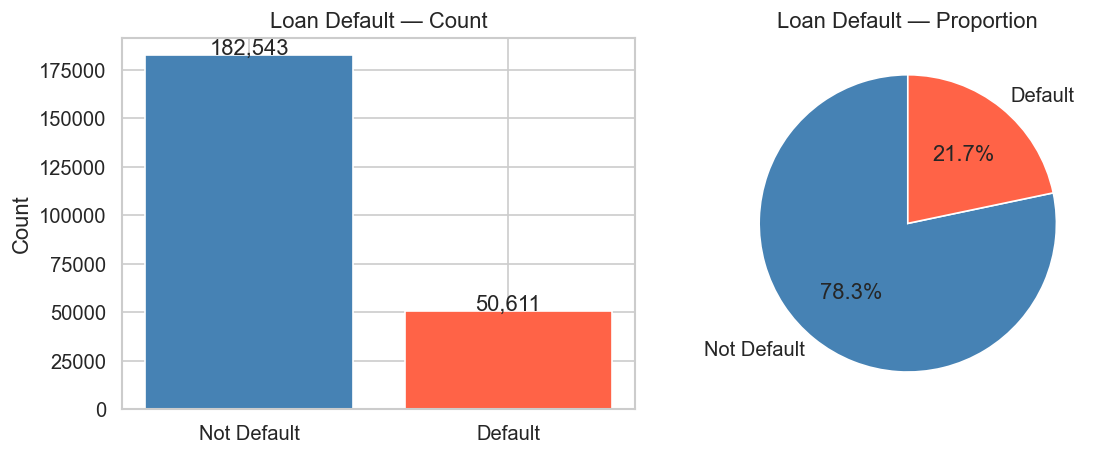

LOAN_DEFAULT
Not Default    182543
Default         50611


In [86]:
# ============================================================
# 5. Target Distribution
# ============================================================
vc = df["LOAN_DEFAULT"].value_counts().rename({0: "Not Default", 1: "Default"})
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(vc.index, vc.values, color=["steelblue", "tomato"])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center")
axes[0].set_title("Loan Default — Count")
axes[0].set_ylabel("Count")

axes[1].pie(vc.values, labels=vc.index, autopct="%1.1f%%",
            colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Loan Default — Proportion")

plt.tight_layout(); plt.show()
print(vc.to_string())


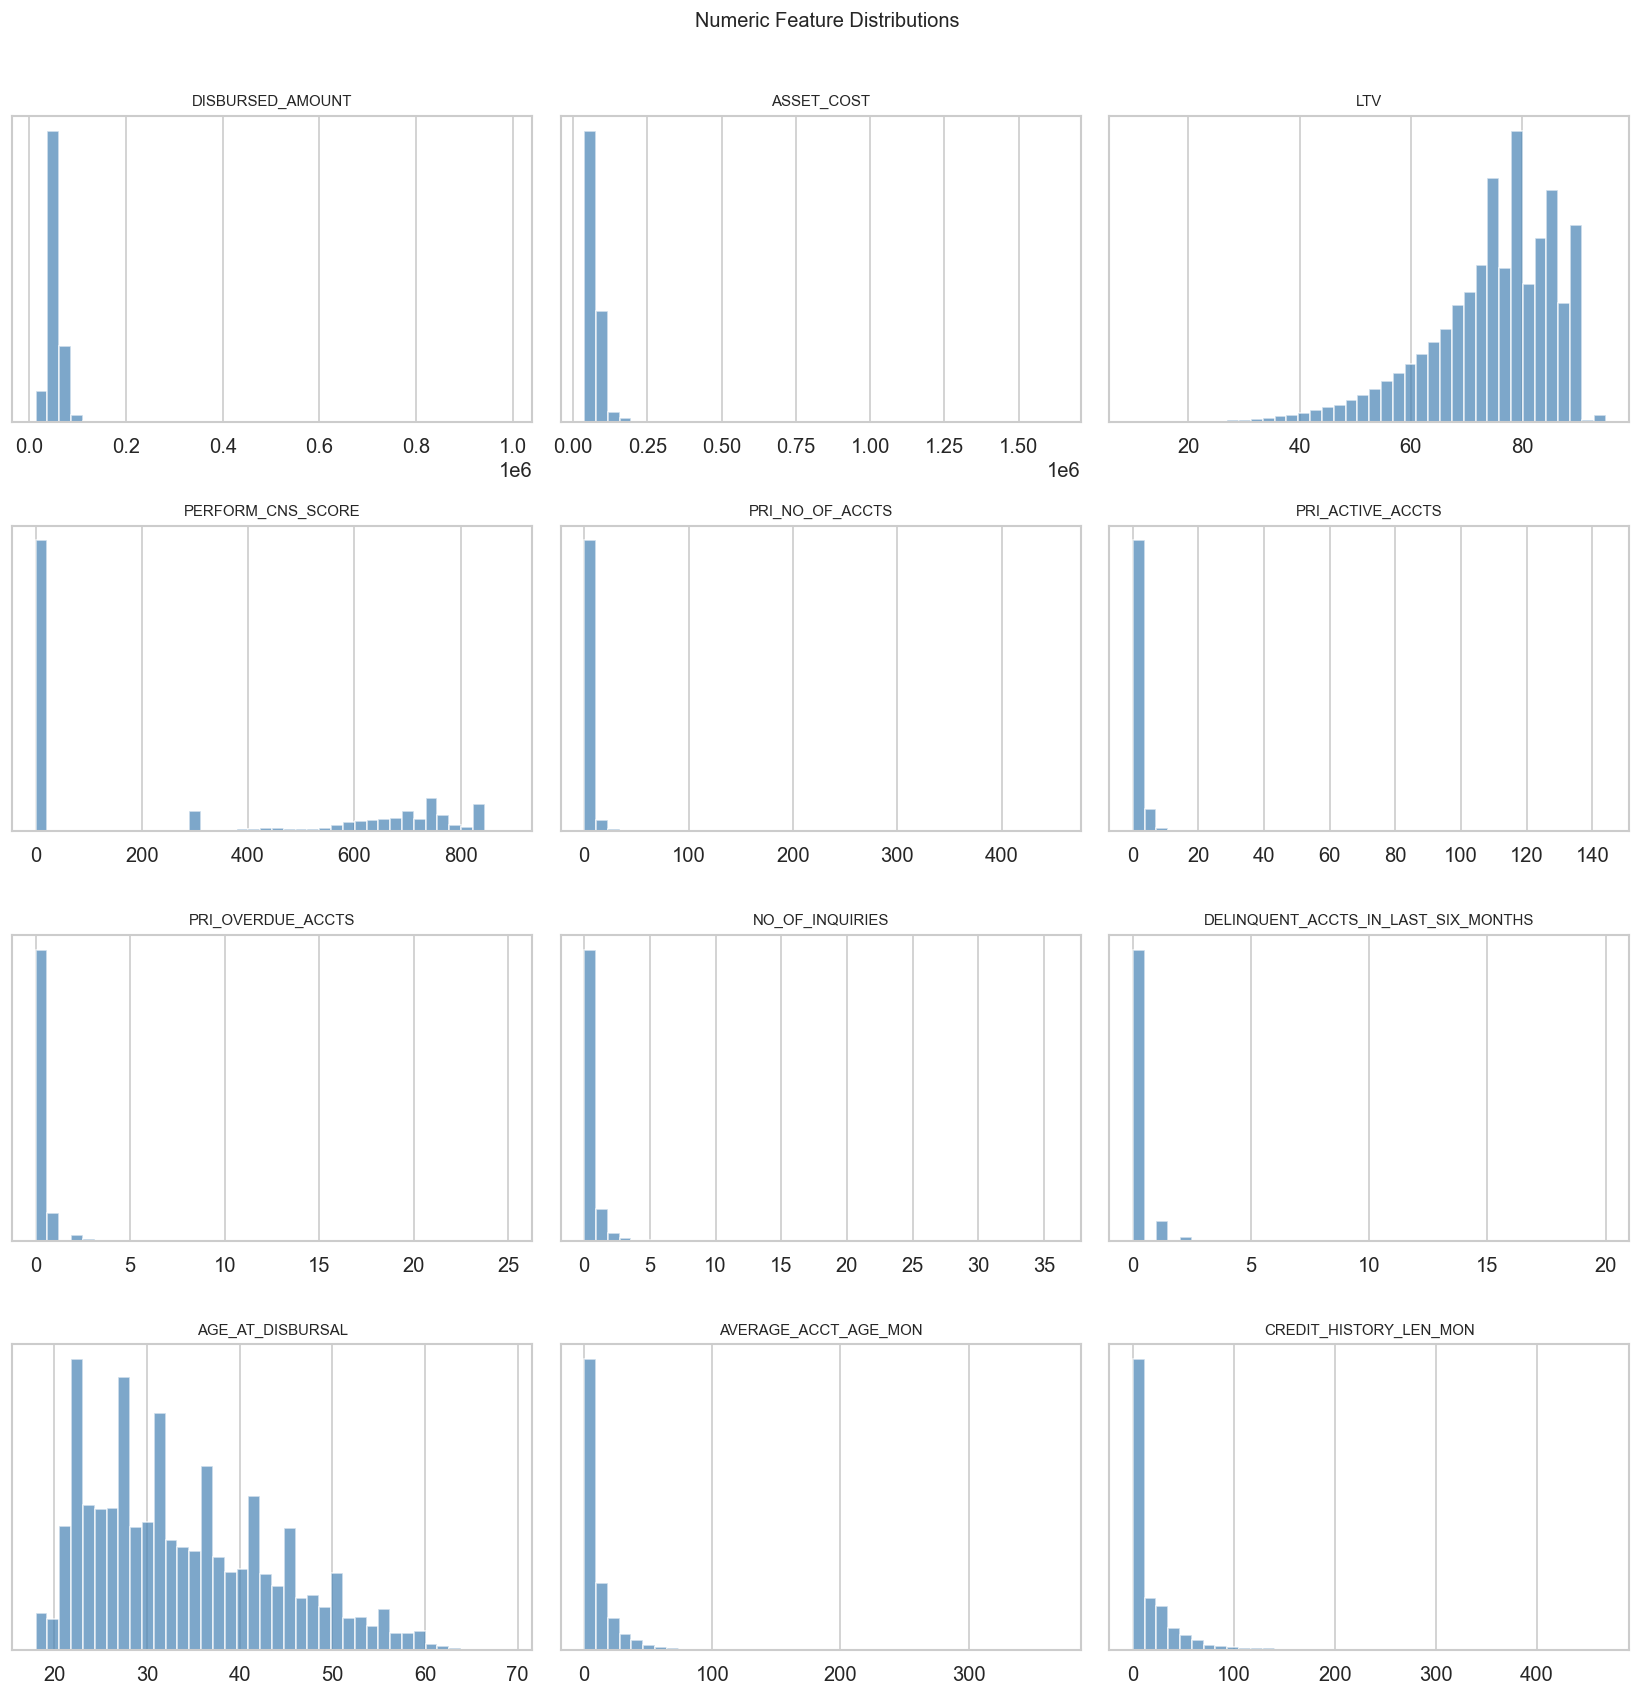

In [100]:
# ============================================================
# 6. Numeric Distributions (histograms + default-rate overlay)
# ============================================================
key_num = [
    "DISBURSED_AMOUNT", "ASSET_COST", "LTV",
     "PERFORM_CNS_SCORE",
    "PRI_NO_OF_ACCTS", "PRI_ACTIVE_ACCTS", "PRI_OVERDUE_ACCTS",
    "NO_OF_INQUIRIES",  "DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS", "AGE_AT_DISBURSAL",  "AVERAGE_ACCT_AGE_MON", "CREDIT_HISTORY_LEN_MON",
]

n_cols = 3
n_rows = -(-len(key_num) // n_cols)   # ceiling div
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(key_num):
    axes[i].hist(df[col].dropna(), bins=40, color="steelblue",
                 edgecolor="white", density=True, alpha=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_yticks([])

# hide unused
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions", y=1.01, fontsize=12)
plt.tight_layout(); plt.show()


EMPLOYMENT_TYPE
Self employed    127635
Salaried          97858
Name: count, dtype: int64
PERFORM_CNS_SCORE_DESCRIPTION
No Bureau History Available                                116950
C-Very Low Risk                                             16045
A-Very Low Risk                                             14124
D-Very Low Risk                                             11358
B-Very Low Risk                                              9201
M-Very High Risk                                             8776
F-Low Risk                                                   8485
K-High Risk                                                  8277
H-Medium Risk                                                6855
E-Low Risk                                                   5821
I-Medium Risk                                                5557
G-Low Risk                                                   3988
Not Scored: Sufficient History Not Available                 3765
J-High Risk           

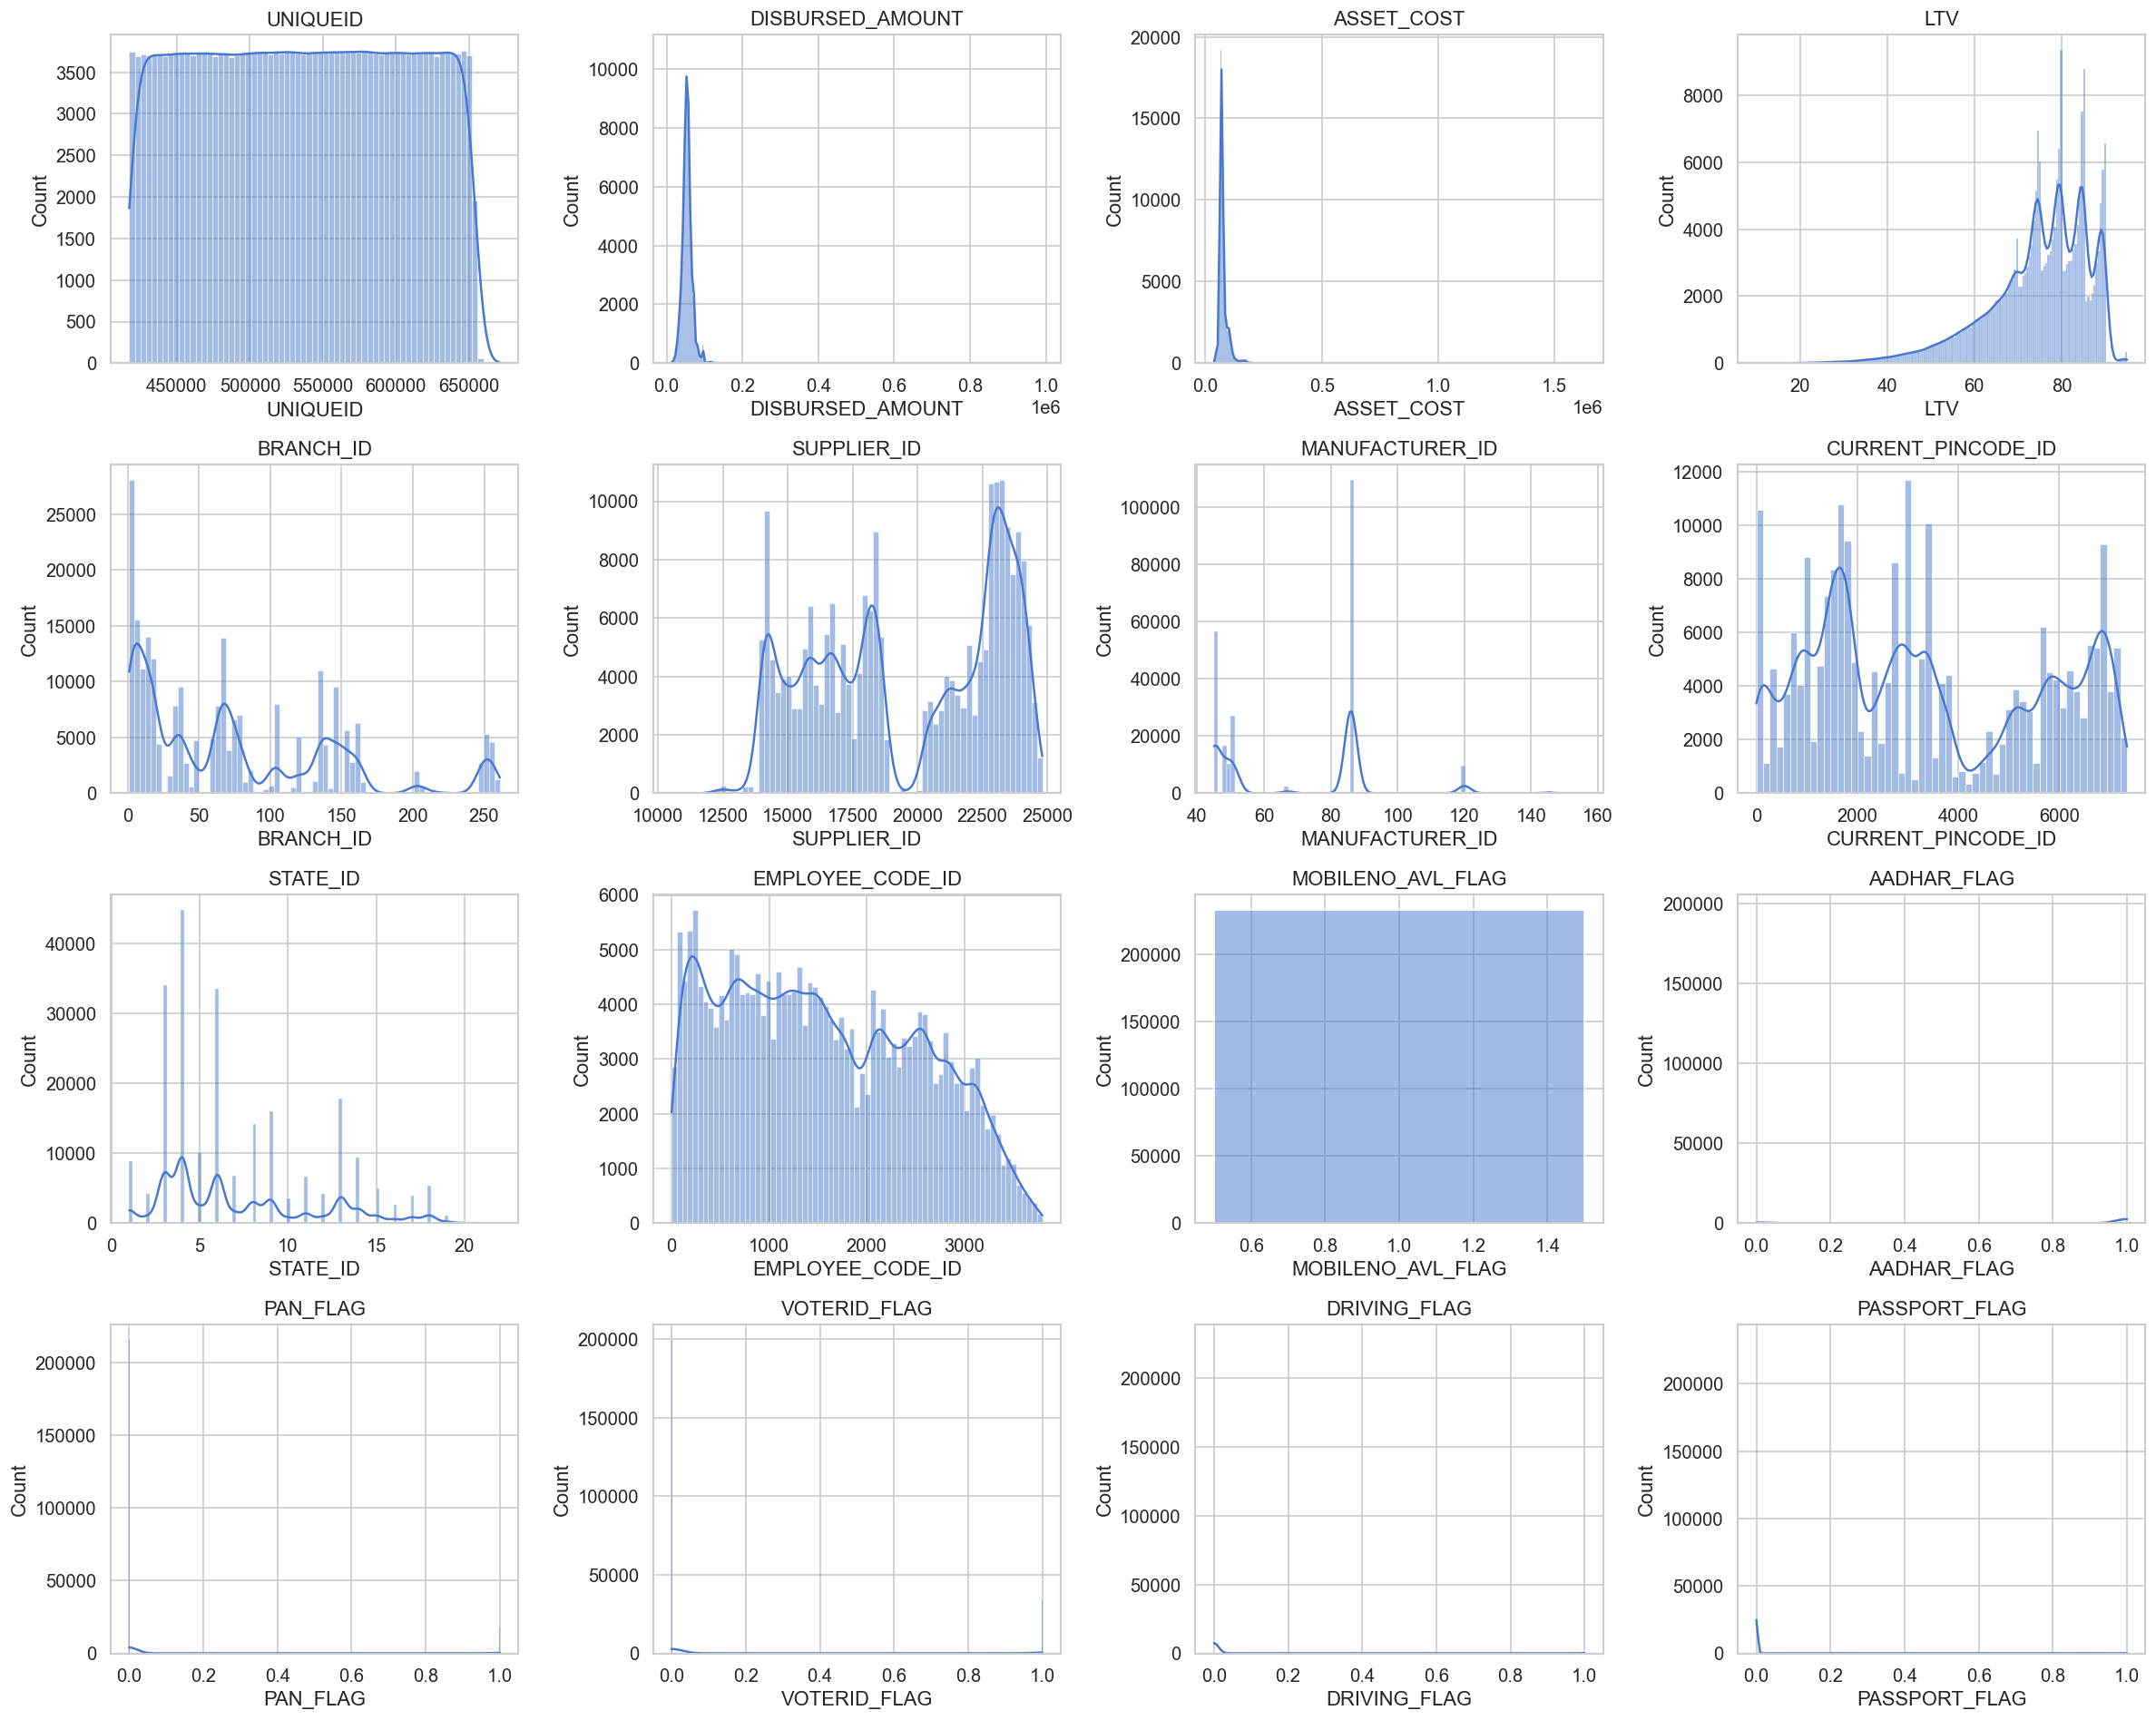

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Numerical Features ---
num_cols = df.select_dtypes(include='number').columns.drop('LOAN_DEFAULT')

# Distribution plot ดู skewness, outlier
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()

# --- Categorical Features ---
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(df[col].value_counts())
    # ดู cardinality สูงผิดปกติไหม? ถ้า unique > 50 อาจต้อง encode พิเศษ


EMPLOYMENT_TYPE:
EMPLOYMENT_TYPE
Self employed    0.227657
Salaried         0.203458
Name: LOAN_DEFAULT, dtype: float64


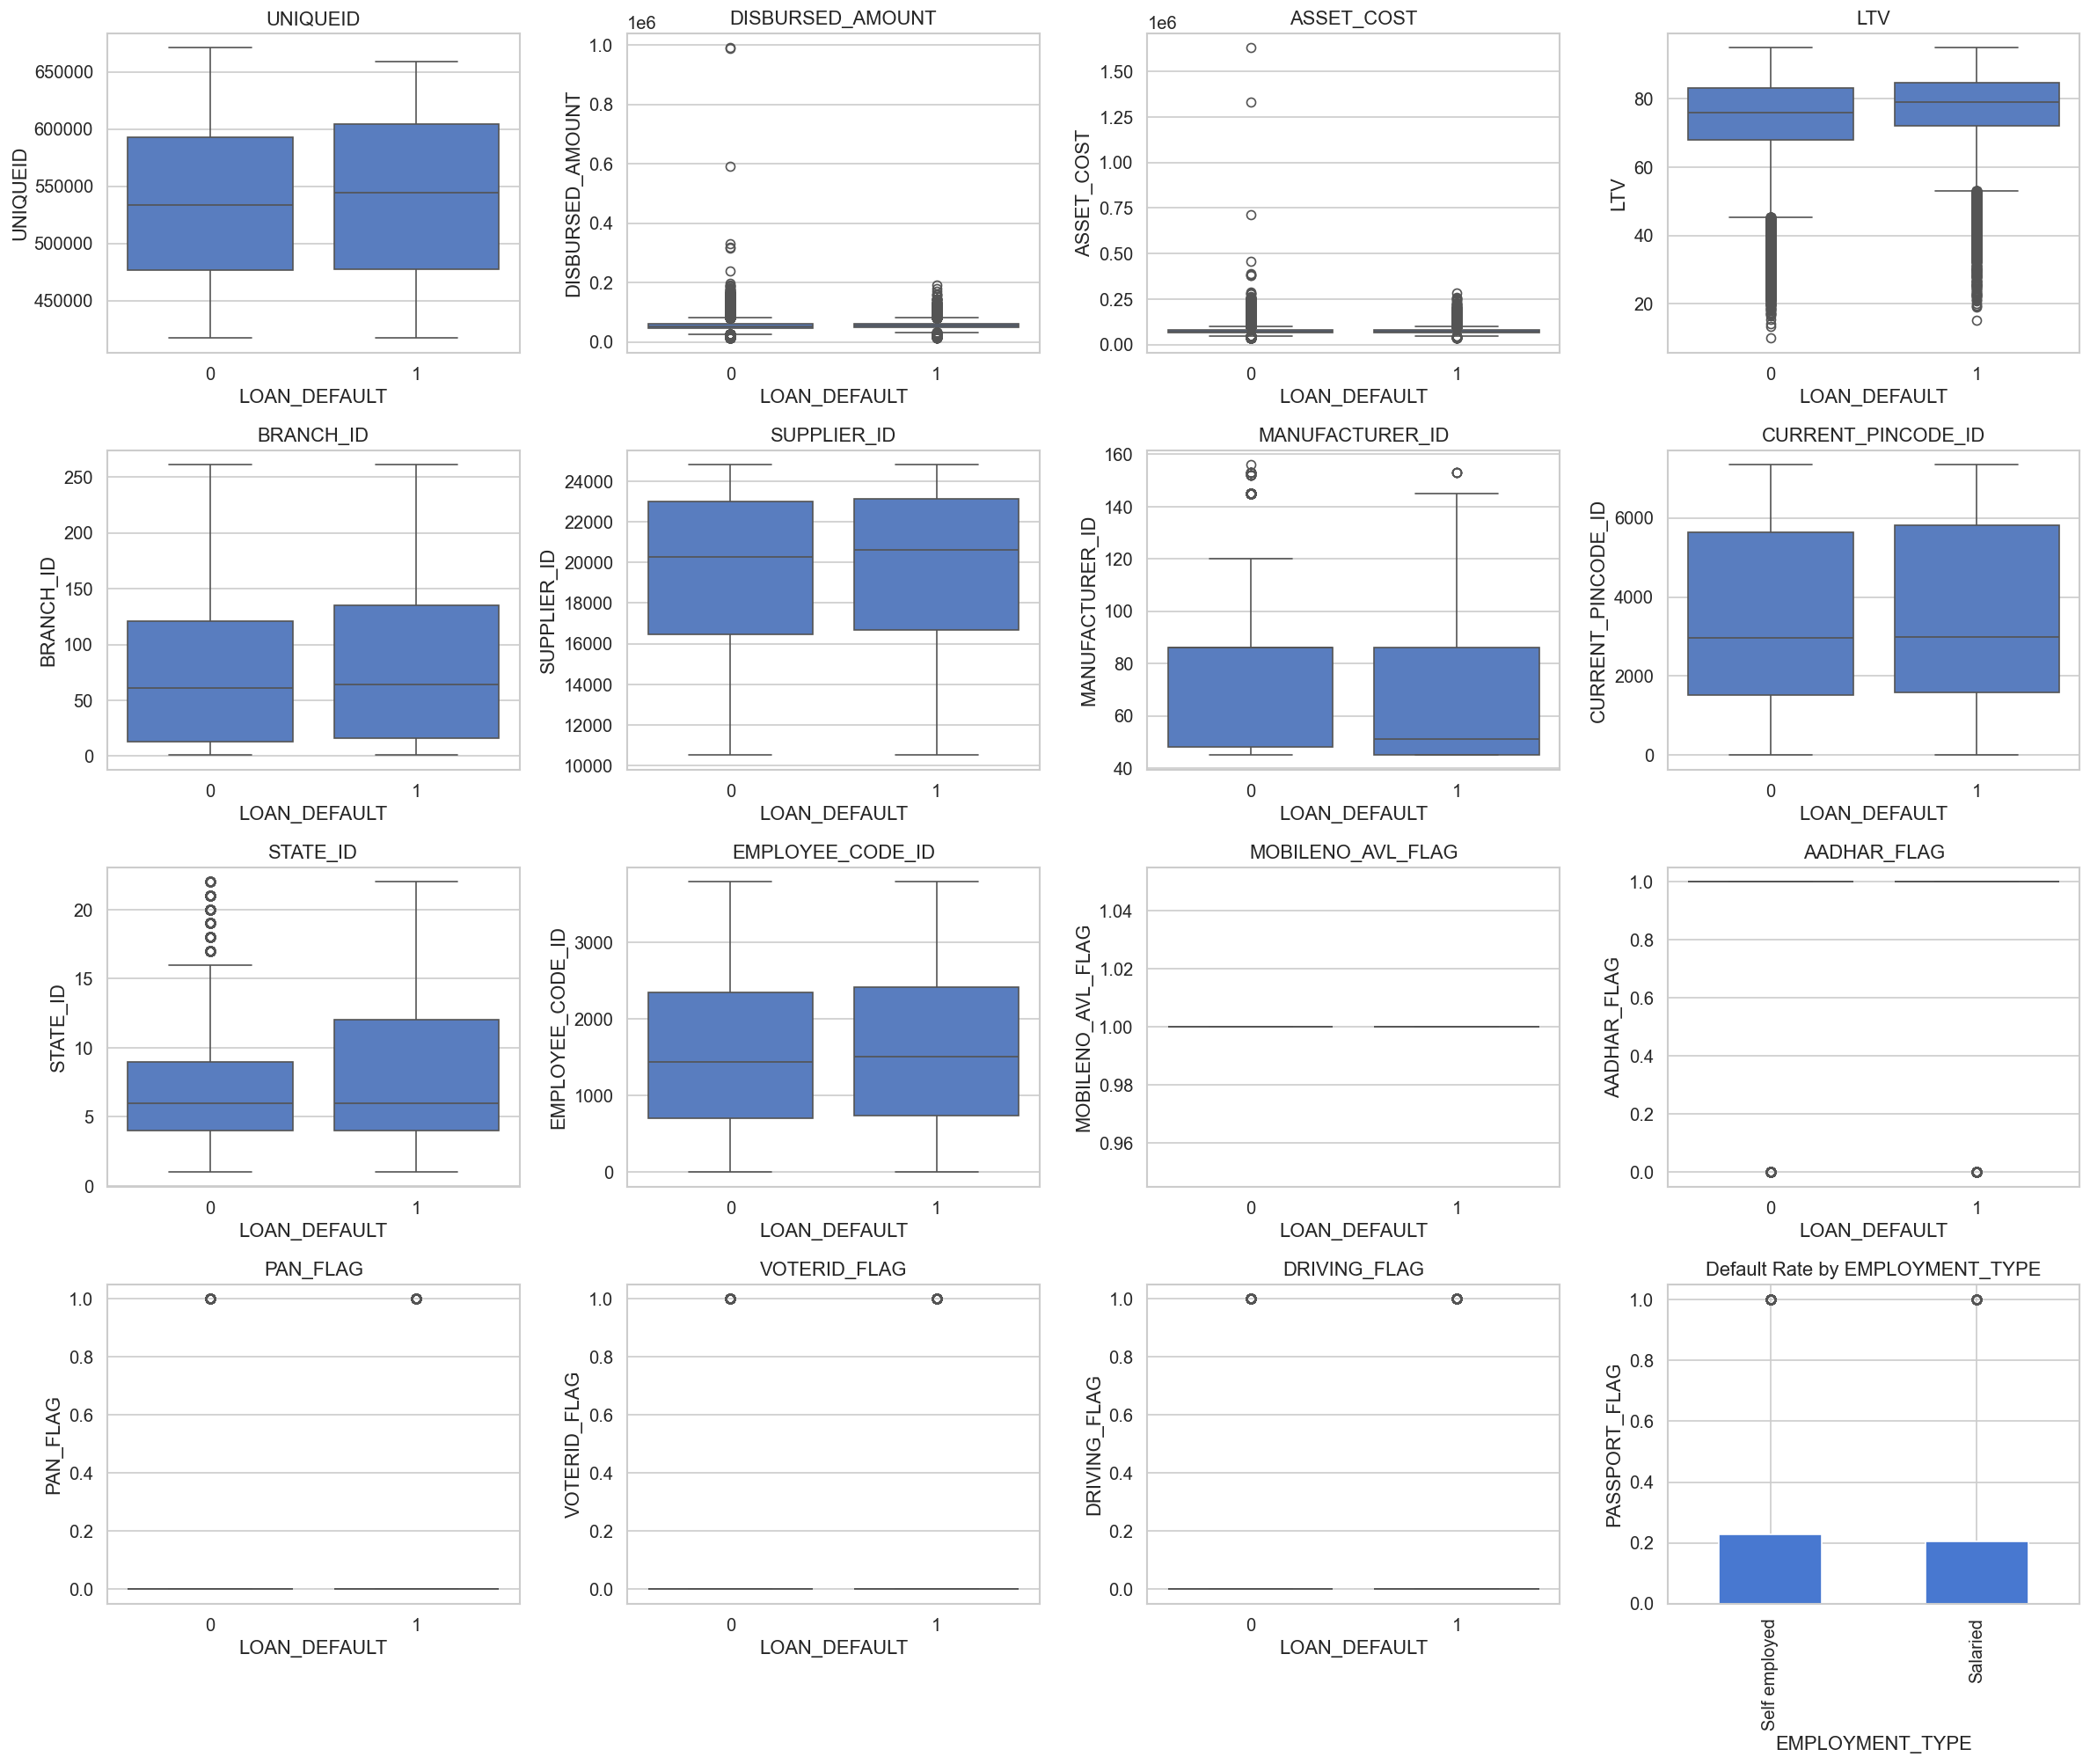


PERFORM_CNS_SCORE_DESCRIPTION:
PERFORM_CNS_SCORE_DESCRIPTION
M-Very High Risk                                           0.304581
L-Very High Risk                                           0.280423
K-High Risk                                                0.278120
I-Medium Risk                                              0.272629
Not Scored: Sufficient History Not Available               0.255777
J-High Risk                                                0.252401
H-Medium Risk                                              0.241867
No Bureau History Available                                0.231313
Not Scored: Only a Guarantor                               0.213115
Not Scored: Not Enough Info available on the customer      0.209695
G-Low Risk                                                 0.197091
Not Scored: No Updates available in last 36 months         0.190352
F-Low Risk                                                 0.186211
Not Scored: No Activity seen on the customer (Inactive

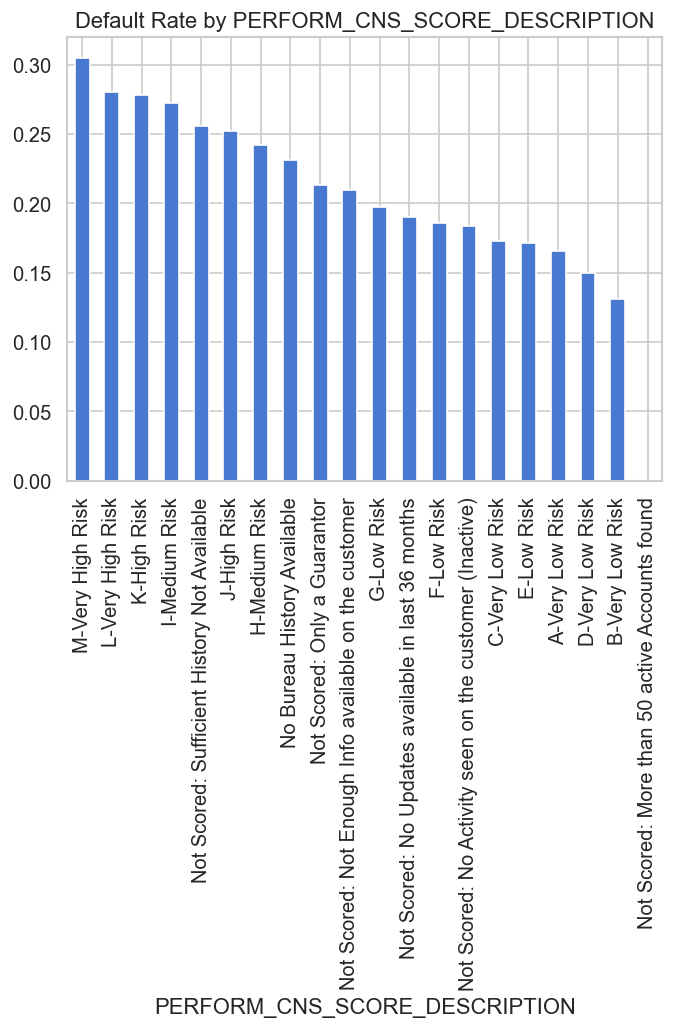


AVERAGE_ACCT_AGE:
AVERAGE_ACCT_AGE
15yrs 8mon     1.000000
14yrs 1mon     1.000000
12yrs 4mon     0.750000
12yrs 5mon     0.666667
9yrs 8mon      0.500000
                 ...   
13yrs 2mon     0.000000
13yrs 11mon    0.000000
14yrs 11mon    0.000000
13yrs 10mon    0.000000
12yrs 11mon    0.000000
Name: LOAN_DEFAULT, Length: 192, dtype: float64


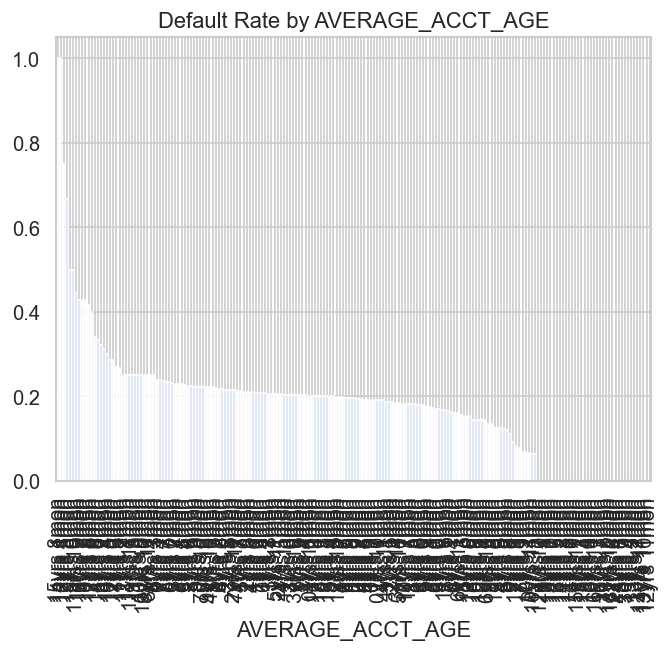


CREDIT_HISTORY_LENGTH:
CREDIT_HISTORY_LENGTH
20yrs 10mon    1.0
24yrs 0mon     1.0
24yrs 2mon     1.0
25yrs 8mon     1.0
27yrs 3mon     1.0
              ... 
19yrs 7mon     0.0
19yrs 8mon     0.0
19yrs 9mon     0.0
20yrs 2mon     0.0
20yrs 6mon     0.0
Name: LOAN_DEFAULT, Length: 294, dtype: float64


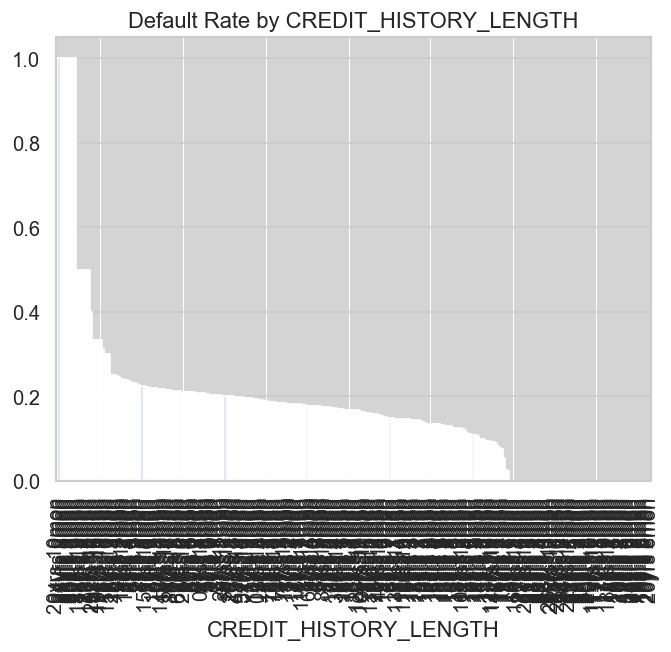

In [107]:
# --- Numerical vs Target: ใช้ boxplot หรือ KDE แยก class ---
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 16))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x='LOAN_DEFAULT', y=col, data=df, ax=ax)
    ax.set_title(col)
plt.tight_layout()

# --- Categorical vs Target: Default Rate ต่อ category ---
for col in cat_cols:
    default_rate = df.groupby(col)['LOAN_DEFAULT'].mean().sort_values(ascending=False)
    print(f"\n{col}:\n{default_rate}")
    default_rate.plot(kind='bar', title=f'Default Rate by {col}')
    plt.show()

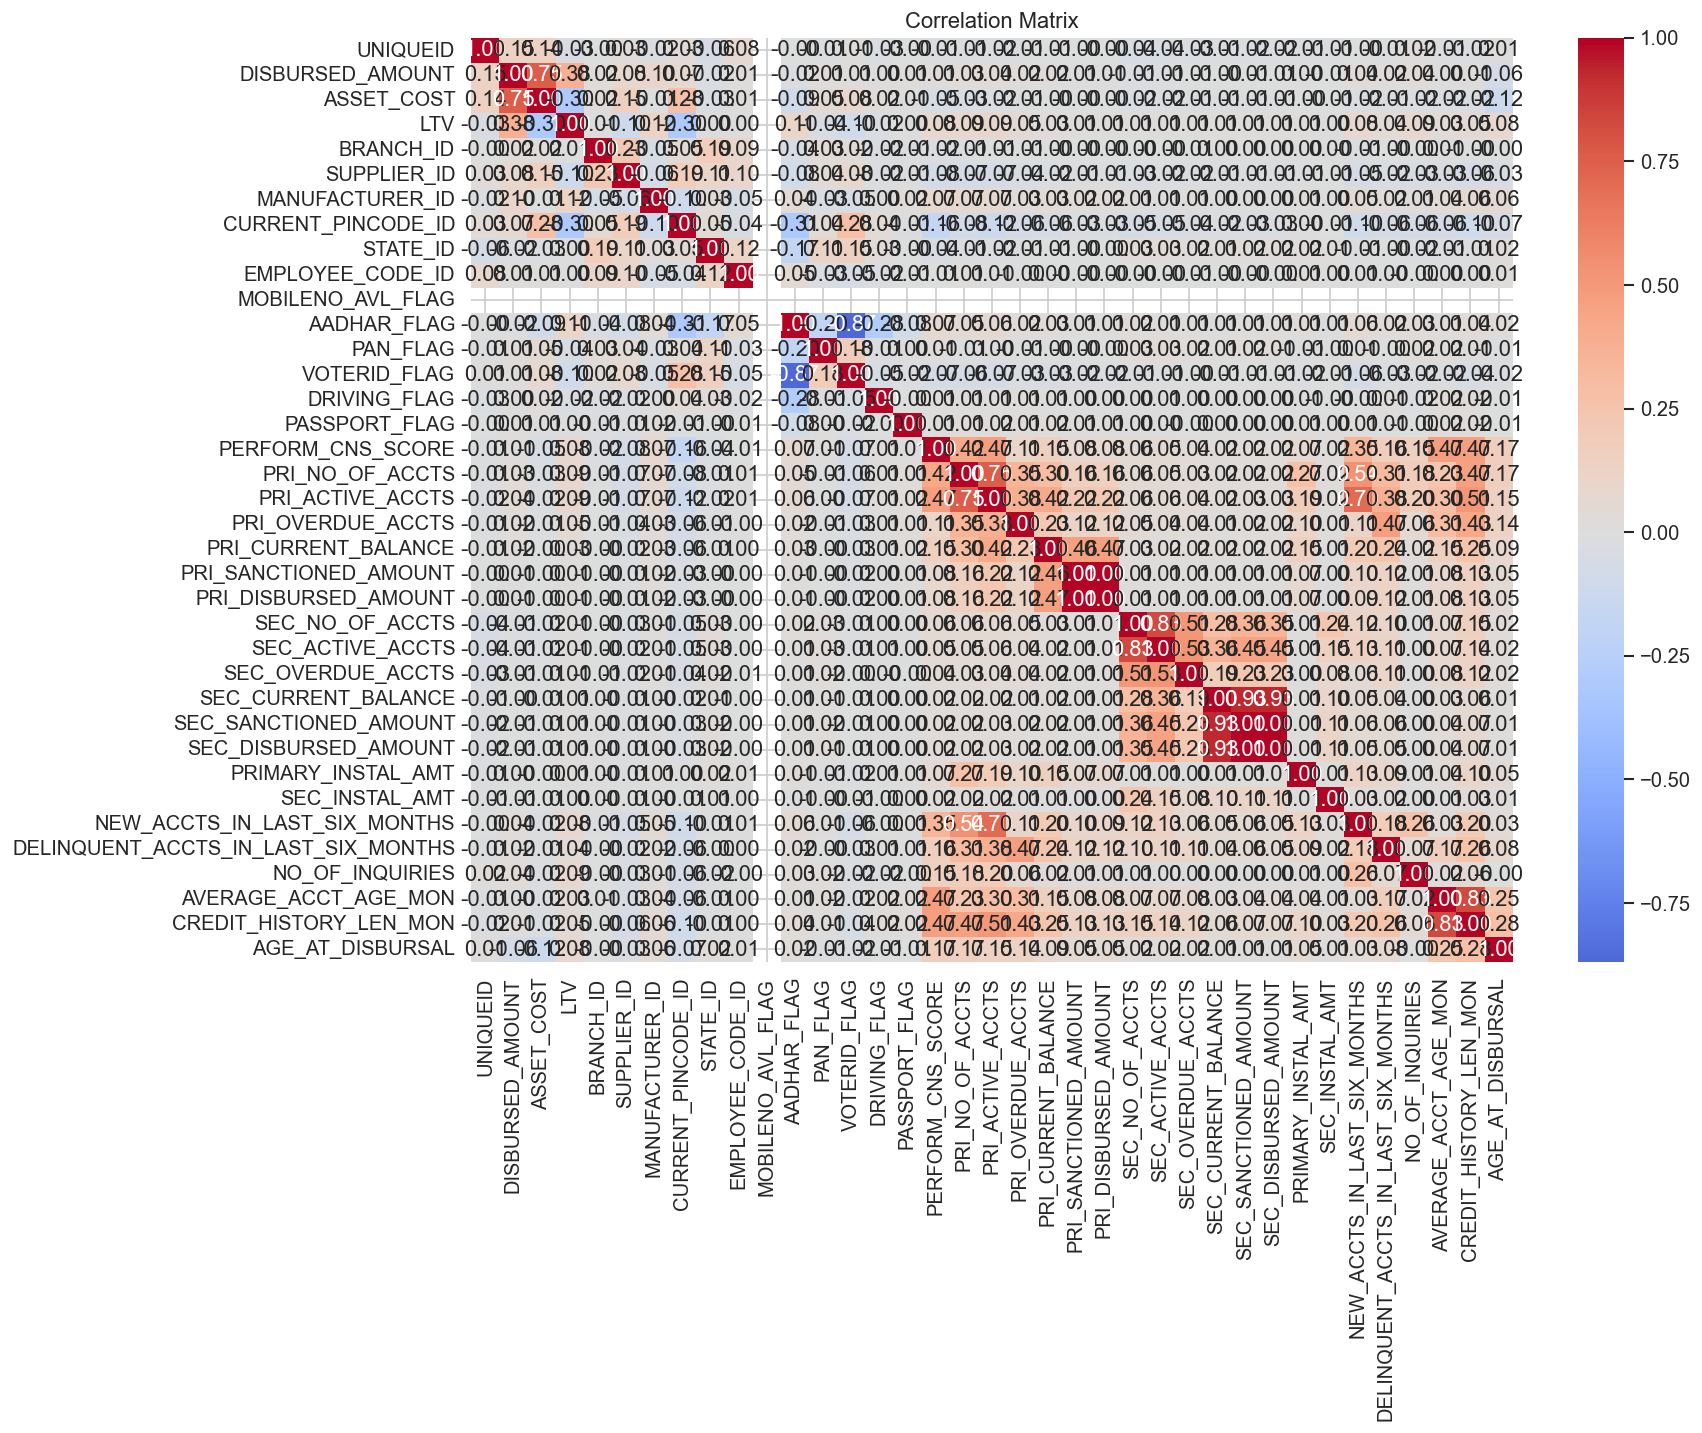

UNIQUEID: r=0.034, p=0.0000
DISBURSED_AMOUNT: r=0.078, p=0.0000
ASSET_COST: r=0.014, p=0.0000
LTV: r=0.098, p=0.0000
BRANCH_ID: r=0.030, p=0.0000
SUPPLIER_ID: r=0.027, p=0.0000
MANUFACTURER_ID: r=-0.025, p=0.0000
CURRENT_PINCODE_ID: r=0.028, p=0.0000
STATE_ID: r=0.048, p=0.0000
EMPLOYEE_CODE_ID: r=0.021, p=0.0000
MOBILENO_AVL_FLAG: r=nan, p=nan
AADHAR_FLAG: r=-0.042, p=0.0000
PAN_FLAG: r=0.002, p=0.3231
VOTERID_FLAG: r=0.044, p=0.0000
DRIVING_FLAG: r=-0.006, p=0.0049
PASSPORT_FLAG: r=-0.008, p=0.0002
PERFORM_CNS_SCORE: r=-0.058, p=0.0000
PRI_NO_OF_ACCTS: r=-0.035, p=0.0000
PRI_ACTIVE_ACCTS: r=-0.041, p=0.0000
PRI_OVERDUE_ACCTS: r=0.041, p=0.0000
PRI_CURRENT_BALANCE: r=-0.027, p=0.0000
PRI_SANCTIONED_AMOUNT: r=-0.011, p=0.0000
PRI_DISBURSED_AMOUNT: r=-0.011, p=0.0000
SEC_NO_OF_ACCTS: r=-0.008, p=0.0001
SEC_ACTIVE_ACCTS: r=-0.006, p=0.0038
SEC_OVERDUE_ACCTS: r=-0.001, p=0.5081
SEC_CURRENT_BALANCE: r=-0.006, p=0.0076
SEC_SANCTIONED_AMOUNT: r=-0.006, p=0.0022
SEC_DISBURSED_AMOUNT: r=-0.006

In [108]:
# Heatmap ดู correlation ระหว่าง numerical features
# ระวัง multicollinearity เช่น loan_amount กับ EMI มักสูงมาก
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Point-Biserial correlation กับ target (เหมาะกับ binary target)
from scipy.stats import pointbiserialr

for col in num_cols:
    corr, pval = pointbiserialr(df[col].dropna(), df.loc[df[col].notna(), 'LOAN_DEFAULT'])
    print(f"{col}: r={corr:.3f}, p={pval:.4f}")

In [97]:
df['cns_score_zero'] = (df['PERFORM_CNS_SCORE'] == 0).astype(int)
df.groupby('cns_score_zero')['LOAN_DEFAULT'].mean()

cns_score_zero
0    0.202738
1    0.231313
Name: LOAN_DEFAULT, dtype: float64

In [87]:
# ============================================================
# 7. Categorical Summary
# ============================================================
cat_cols = ["EMPLOYMENT_TYPE", "PERFORM_CNS_SCORE_DESCRIPTION"]

for col in cat_cols:
    vc = df[col].value_counts(dropna=False)
    dr = df.groupby(col, dropna=False)["LOAN_DEFAULT"].mean().rename("default_rate")
    summary = pd.concat([vc.rename("count"), dr], axis=1)
    summary["count_%"] = (summary["count"] / len(df) * 100).round(1)
    print(f"\n── {col} ──")
    display(summary.sort_values("count", ascending=False))



── EMPLOYMENT_TYPE ──


,count,default_rate,count_%
EMPLOYMENT_TYPE,,,
Self employed,127635,0.227657,54.7
Salaried,97858,0.203458,42.0
NaN,7661,0.214593,3.3



── PERFORM_CNS_SCORE_DESCRIPTION ──


,count,default_rate,count_%
PERFORM_CNS_SCORE_DESCRIPTION,,,
No Bureau History Available,116950,0.231313,50.2
C-Very Low Risk,16045,0.172639,6.9
A-Very Low Risk,14124,0.165746,6.1
D-Very Low Risk,11358,0.149586,4.9
B-Very Low Risk,9201,0.131290,3.9
M-Very High Risk,8776,0.304581,3.8
F-Low Risk,8485,0.186211,3.6
K-High Risk,8277,0.278120,3.6
H-Medium Risk,6855,0.241867,2.9


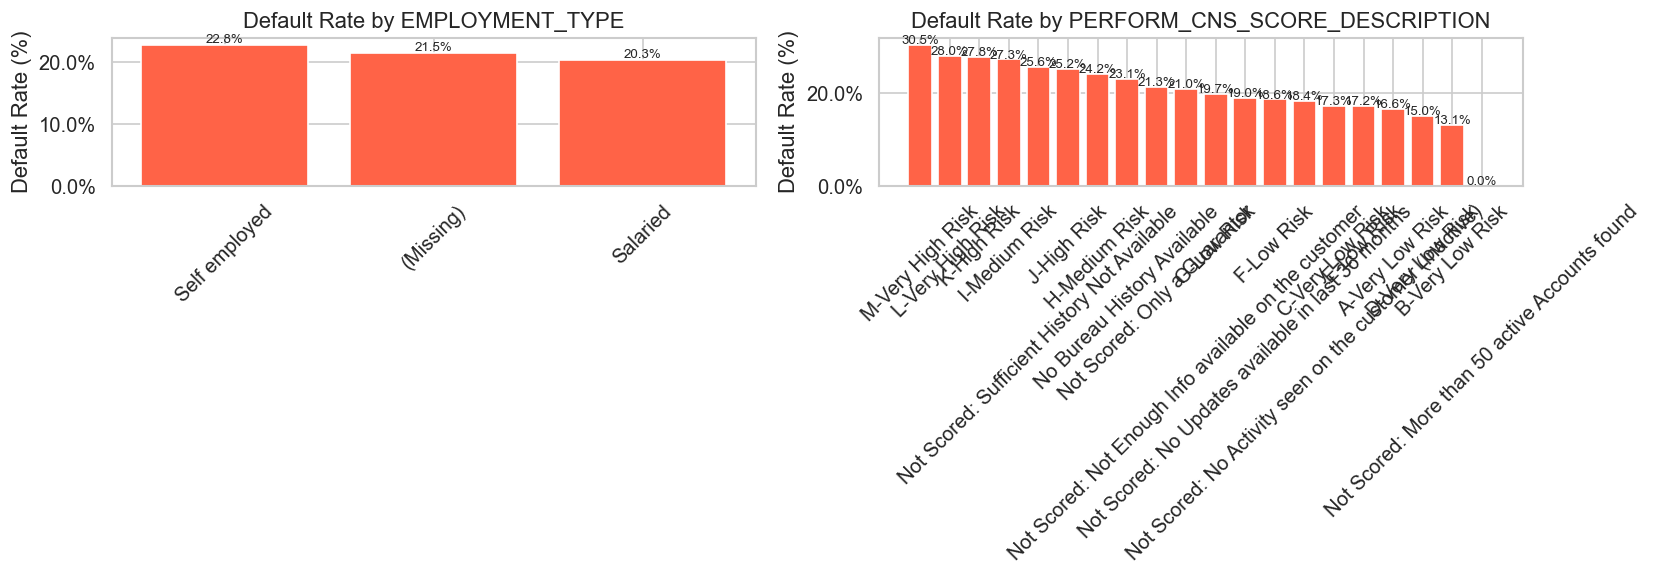

In [101]:
# ============================================================
# 8. Default Rate by Key Categorical Features (bar chart)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    # fill NaN ก่อน groupby เพื่อป้องกัน float index
    dr = (df[col].fillna("(Missing)")
            .pipe(lambda s: df.assign(**{col: s}))
            .groupby(col)["LOAN_DEFAULT"].mean()
            .sort_values(ascending=False))
    
    ax.bar(dr.index.astype(str), dr.values * 100, color="tomato")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f"Default Rate by {col}")
    ax.set_ylabel("Default Rate (%)")
    ax.tick_params(axis="x", rotation=45)
    for j, v in enumerate(dr.values):
        ax.text(j, v * 100 + 0.3, f"{v:.1%}", ha="center", fontsize=8)

plt.tight_layout(); plt.show()


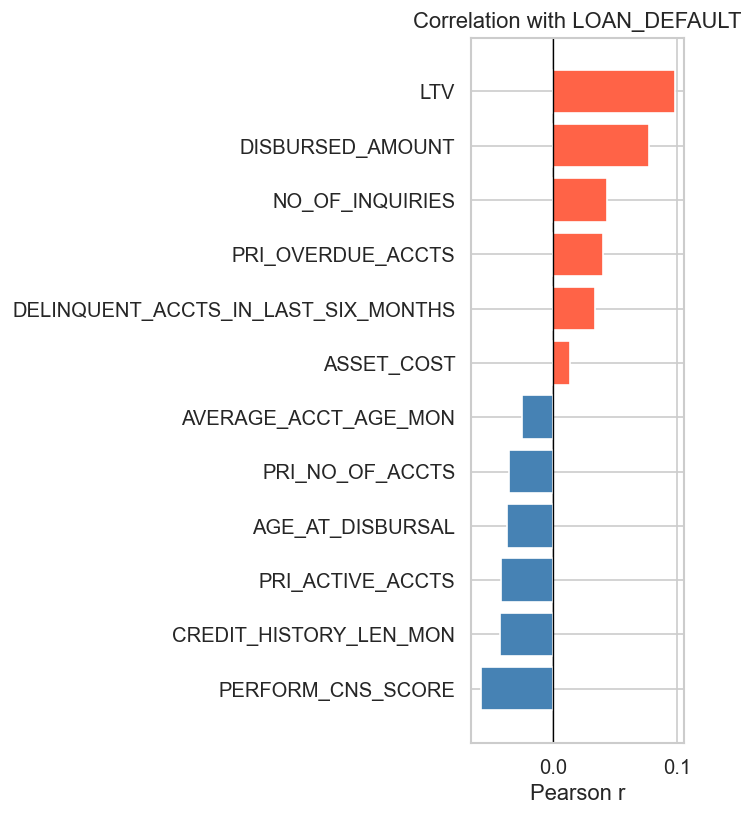

PERFORM_CNS_SCORE                     -0.057929
CREDIT_HISTORY_LEN_MON                -0.042126
PRI_ACTIVE_ACCTS                      -0.041451
AGE_AT_DISBURSAL                      -0.036549
PRI_NO_OF_ACCTS                       -0.035456
AVERAGE_ACCT_AGE_MON                  -0.024781
ASSET_COST                             0.014261
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS    0.034462
PRI_OVERDUE_ACCTS                      0.040872
NO_OF_INQUIRIES                        0.043678
DISBURSED_AMOUNT                       0.077675
LTV                                    0.098208


In [102]:
# ============================================================
# 9. Correlation Heatmap (numeric cols vs target)
# ============================================================
corr_cols = key_num + ["LOAN_DEFAULT"]
corr = df[corr_cols].corr()["LOAN_DEFAULT"].drop("LOAN_DEFAULT").sort_values()

fig, ax = plt.subplots(figsize=(6, len(corr) * 0.5 + 1))
colors = ["tomato" if v > 0 else "steelblue" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation with LOAN_DEFAULT")
ax.set_xlabel("Pearson r")
plt.tight_layout(); plt.show()
print(corr.to_string())


In [103]:
df.select_dtypes(include='number').corr()

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,STATE_ID,EMPLOYEE_CODE_ID,...,SEC_DISBURSED_AMOUNT,PRIMARY_INSTAL_AMT,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,NO_OF_INQUIRIES,LOAN_DEFAULT,AVERAGE_ACCT_AGE_MON,CREDIT_HISTORY_LEN_MON,AGE_AT_DISBURSAL
UNIQUEID,1.000000,0.145575,0.144671,-0.030537,-0.004509,0.025747,-0.021514,0.030500,-0.057734,0.075983,...,-0.016857,-0.009321,-0.013518,-0.003842,-0.009186,0.016537,0.033848,-0.011912,-0.018799,0.010072
DISBURSED_AMOUNT,0.145575,1.000000,0.752668,0.376747,0.018328,0.078596,0.095203,0.068540,-0.023956,0.010120,...,-0.005119,0.002350,-0.005525,0.035880,0.020198,0.038513,0.077675,0.004205,0.013402,-0.059193
ASSET_COST,0.144671,0.752668,1.000000,-0.301188,0.018586,0.150002,-0.005256,0.275878,-0.026348,0.008711,...,-0.010594,-0.004356,-0.005738,-0.021968,-0.007932,-0.017301,0.014261,-0.015614,-0.023563,-0.117898
LTV,-0.030537,0.376747,-0.301188,1.000000,0.006382,-0.103732,0.121003,-0.300112,0.004882,0.004940,...,0.008733,0.007358,0.000481,0.083824,0.041921,0.085725,0.098208,0.029853,0.053607,0.081010
BRANCH_ID,-0.004509,0.018328,0.018586,0.006382,1.000000,0.225744,-0.049957,0.048192,0.187782,0.088764,...,0.002457,0.004955,0.004265,-0.008354,-0.001730,-0.001813,0.030193,0.005338,-0.002577,-0.003335
SUPPLIER_ID,0.025747,0.078596,0.150002,-0.103732,0.225744,1.000000,-0.063916,0.187401,0.105502,0.095792,...,-0.010031,-0.011953,-0.005826,-0.053264,-0.024622,-0.030988,0.027357,-0.034095,-0.061370,-0.033905
MANUFACTURER_ID,-0.021514,0.095203,-0.005256,0.121003,-0.049957,-0.063916,1.000000,-0.104349,0.026412,-0.045009,...,0.003301,0.014116,0.003020,0.050079,0.019438,0.010012,-0.025039,0.042522,0.061534,0.056123
CURRENT_PINCODE_ID,0.030500,0.068540,0.275878,-0.300112,0.048192,0.187401,-0.104349,1.000000,0.047903,-0.042609,...,-0.025630,0.002275,-0.006305,-0.100080,-0.057419,-0.058821,0.028419,-0.062704,-0.095906,-0.070329
STATE_ID,-0.057734,-0.023956,-0.026348,0.004882,0.187782,0.105502,0.026412,0.047903,1.000000,0.117309,...,0.017651,0.015843,0.009850,-0.014942,-0.000655,-0.016129,0.048075,-0.008205,-0.014526,0.020778
EMPLOYEE_CODE_ID,0.075983,0.010120,0.008711,0.004940,0.088764,0.095792,-0.045009,-0.042609,0.117309,1.000000,...,-0.002224,0.013470,0.001894,0.005473,0.003624,-0.002108,0.020657,0.000297,0.002189,0.012590


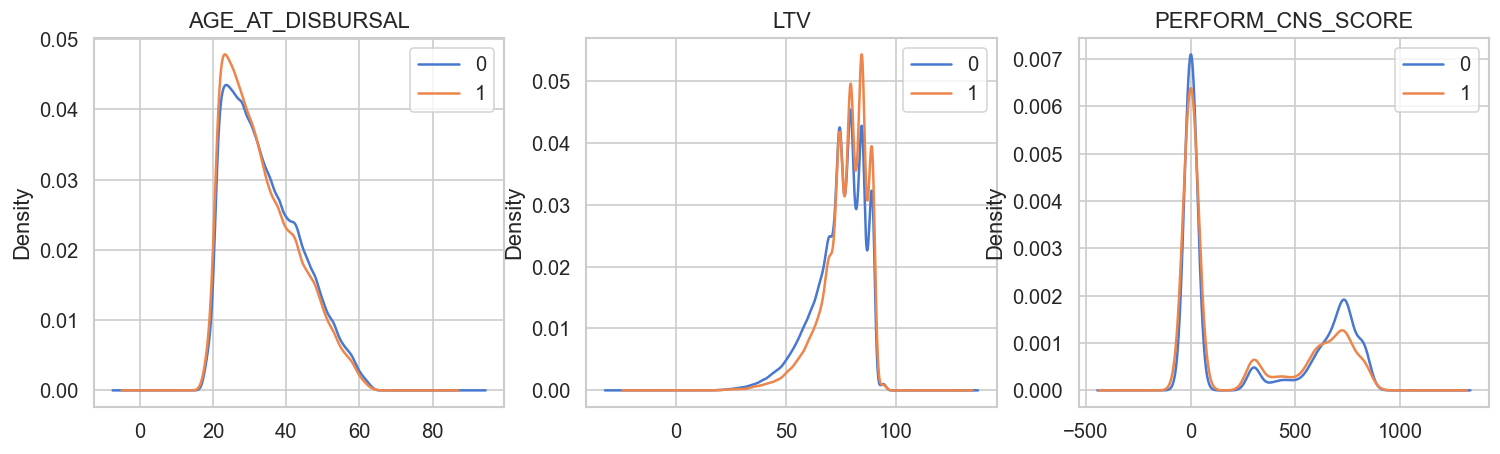

In [105]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['AGE_AT_DISBURSAL', 'LTV', 'PERFORM_CNS_SCORE']):
    df.groupby('LOAN_DEFAULT')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)

In [109]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

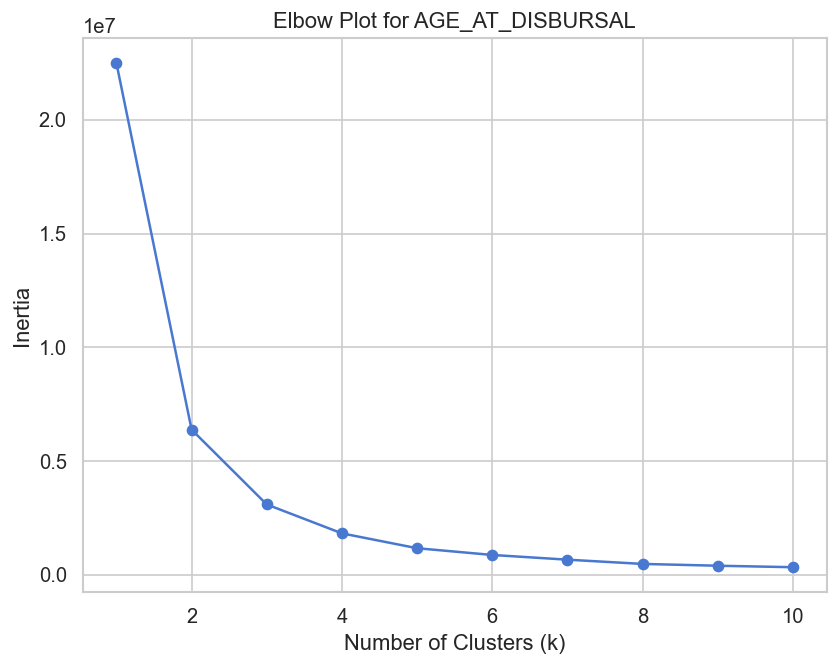

In [110]:
# Create a range of k values to test
k_range = range(1, 11)

# Initialize an empty list to store the inertia values
inertia_values = []

# Iterate over the k values and fit a KMeans model for each
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[['AGE_AT_DISBURSAL']])  # Fit on the 'TX_AMOUNT' column only
    inertia_values.append(kmeans.inertia_)

# Plot the elbow plot
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot for AGE_AT_DISBURSAL')
plt.show()

In [111]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# สร้างช่วงของ k ที่จะทดสอบ (เริ่มที่ 2)
k_range_sil = range(2, 11)
silhouette_scores = []

# คำนวณ Silhouette Score สำหรับแต่ละค่า k
for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(df[['AGE_AT_DISBURSAL']])
    
    # คำนวณ silhouette score
    score = silhouette_score(df[['AGE_AT_DISBURSAL']], cluster_labels)
    silhouette_scores.append(score)
    print(f'For n_clusters = {k}, the average silhouette_score is : {score:.4f}')

# พล็อตกราฟ Silhouette Score
plt.figure(figsize=(8, 6))
plt.plot(k_range_sil, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Score for AGE_AT_DISBURSAL')
plt.grid(True)
plt.show()

For n_clusters = 2, the average silhouette_score is : 0.6229
For n_clusters = 3, the average silhouette_score is : 0.5794
For n_clusters = 4, the average silhouette_score is : 0.5562
For n_clusters = 5, the average silhouette_score is : 0.5588


KeyboardInterrupt: 

In [119]:

# from the elbow plot.
optimal_k = 3

# Perform KMeans clustering with the optimal k
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['AGE_AT_DISBURSAL_CLUSTER'] = kmeans.fit_predict(df[['AGE_AT_DISBURSAL']])
df[['AGE_AT_DISBURSAL', 'AGE_AT_DISBURSAL_CLUSTER']]

,AGE_AT_DISBURSAL,AGE_AT_DISBURSAL_CLUSTER
0,34,2
1,33,2
2,32,2
3,24,1
4,40,2
...,...,...
233149,30,1
233150,29,1
233151,42,2
233152,24,1


<Axes: xlabel='AGE_AT_DISBURSAL_CLUSTER'>

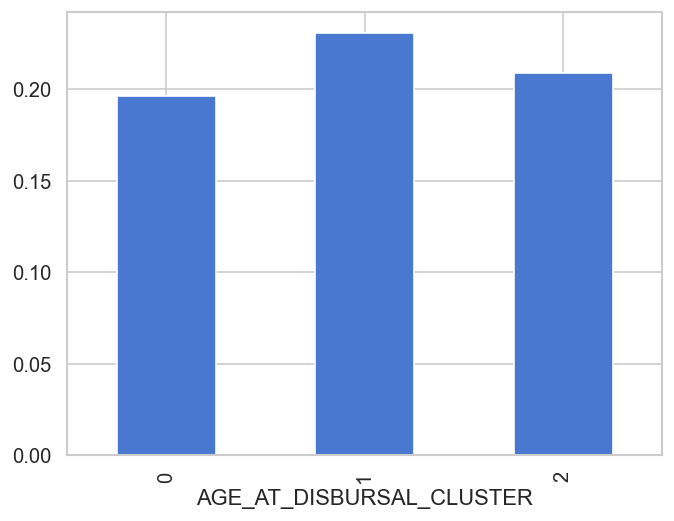

In [120]:
# แล้ว plot default rate ตาม derived features เหล่านี้
df.groupby('AGE_AT_DISBURSAL_CLUSTER')['LOAN_DEFAULT'].mean().plot(kind='bar')

                             count       mean       std   min   25%   50%  \
AGE_AT_DISBURSAL_CLUSTER                                                    
0                          43671.0  49.750956  4.601708  44.0  46.0  49.0   
1                         111196.0  25.596550  3.322035  18.0  23.0  26.0   
2                          78287.0  37.012991  3.465071  32.0  34.0  37.0   

                           75%   max  
AGE_AT_DISBURSAL_CLUSTER              
0                         53.0  69.0  
1                         28.0  31.0  
2                         40.0  43.0  


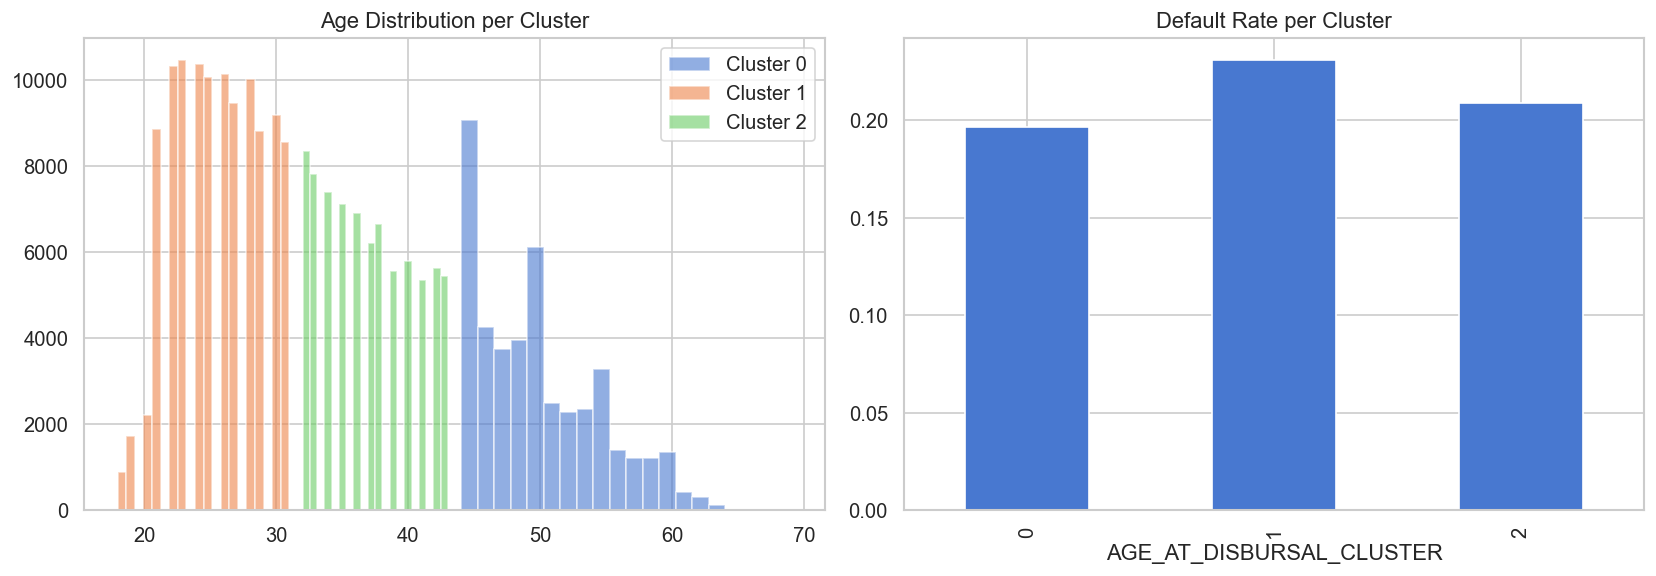

In [122]:
# ดู age range ของแต่ละ cluster
print(df.groupby('AGE_AT_DISBURSAL_CLUSTER')['AGE_AT_DISBURSAL'].describe())

# ถ้าอยากได้ภาพชัดขึ้น
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution ของอายุแต่ละ cluster
for cluster in sorted(df['AGE_AT_DISBURSAL_CLUSTER'].unique()):
    subset = df[df['AGE_AT_DISBURSAL_CLUSTER'] == cluster]['AGE_AT_DISBURSAL']
    axes[0].hist(subset, alpha=0.6, label=f'Cluster {cluster}', bins=20)
axes[0].set_title('Age Distribution per Cluster')
axes[0].legend()

# Right: default rate per cluster (ที่คุณทำแล้ว)
df.groupby('AGE_AT_DISBURSAL_CLUSTER')['LOAN_DEFAULT'].mean().plot(
    kind='bar', ax=axes[1], title='Default Rate per Cluster'
)
plt.tight_layout()

In [127]:
# Rename cluster ให้เรียงตามอายุ เพื่อไม่ให้ model สับสน
age_order = df.groupby('AGE_AT_DISBURSAL_CLUSTER')['AGE_AT_DISBURSAL'].mean().sort_values()
cluster_rename = {old: new for new, old in enumerate(age_order.index)}
df['AGE_CLUSTER_ORDERED'] = df['AGE_AT_DISBURSAL_CLUSTER'].map(cluster_rename)
# ตอนนี้ 0=อายุน้อย, 1=อายุกลาง, 2=อายุมาก

In [112]:
from scipy import stats

# IQR method
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_count = ((df[num_cols] < Q1 - 1.5*IQR) | (df[num_cols] > Q3 + 1.5*IQR)).sum()
print(outlier_count.sort_values(ascending=False))

NEW_ACCTS_IN_LAST_SIX_MONTHS           51660
PRI_CURRENT_BALANCE                    41044
PRI_DISBURSED_AMOUNT                   39712
PRI_SANCTIONED_AMOUNT                  39587
PRIMARY_INSTAL_AMT                     38868
AADHAR_FLAG                            37230
VOTERID_FLAG                           33794
PRI_ACTIVE_ACCTS                       32534
NO_OF_INQUIRIES                        31193
PRI_OVERDUE_ACCTS                      26275
ASSET_COST                             24388
PRI_NO_OF_ACCTS                        21914
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS    18195
PAN_FLAG                               17621
CREDIT_HISTORY_LEN_MON                 16056
AVERAGE_ACCT_AGE_MON                   15924
DISBURSED_AMOUNT                        9868
LTV                                     6170
SEC_NO_OF_ACCTS                         5865
DRIVING_FLAG                            5419
SEC_ACTIVE_ACCTS                        3817
SEC_SANCTIONED_AMOUNT                   3736
SEC_DISBUR

In [128]:
import numpy as np

# Log transform สำหรับ right-skewed columns ที่มี outlier เยอะ
# +1 เพื่อหลีกเลี่ยง log(0) ซึ่งจะได้ -inf
skewed_cols = [
    'NEW_ACCTS_IN_LAST_SIX_MONTHS', 'PRI_CURRENT_BALANCE',
    'PRI_DISBURSED_AMOUNT', 'PRI_SANCTIONED_AMOUNT',
    'PRIMARY_INSTAL_AMT', 'DISBURSED_AMOUNT', 'ASSET_COST'
]

for col in skewed_cols:
    df[f'{col}_LOG'] = np.log1p(df[col])

# ตรวจสอบว่า skewness ลดลงจริง
original_skew = df[skewed_cols].skew()
log_skew = df[[f'{col}_LOG' for col in skewed_cols]].skew()
print(pd.DataFrame({'original': original_skew.values,
                    'after_log': log_skew.values},
                   index=skewed_cols))

                                original  after_log
NEW_ACCTS_IN_LAST_SIX_MONTHS    4.839326   2.052650
PRI_CURRENT_BALANCE            29.425813        NaN
PRI_DISBURSED_AMOUNT          322.541495   0.487272
PRI_SANCTIONED_AMOUNT         323.697212   0.481521
PRIMARY_INSTAL_AMT             69.916156   0.940679
DISBURSED_AMOUNT                4.492240  -0.454610
ASSET_COST                      6.133485   1.279172


In [124]:
# ตรวจสอบก่อนว่า outlier เหล่านี้มี default rate สูงกว่า normal ไหม
# ถ้าสูงกว่า → มัน signal ที่ดี อย่าลบออก!
col = 'NEW_ACCTS_IN_LAST_SIX_MONTHS'
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

is_outlier = (df[col] > Q3 + 1.5 * IQR) | (df[col] < Q1 - 1.5 * IQR)

print(f"Default rate ใน outliers  : {df[is_outlier]['LOAN_DEFAULT'].mean():.3f}")
print(f"Default rate ใน non-outliers: {df[~is_outlier]['LOAN_DEFAULT'].mean():.3f}")

Default rate ใน outliers  : 0.192
Default rate ใน non-outliers: 0.224


In [117]:
# อัตราส่วน overdue ต่อ total accounts → วัด "ประวัติเสีย"
df['PRI_OVERDUE_RATIO'] = df['PRI_OVERDUE_ACCTS'] / (df['PRI_NO_OF_ACCTS'] + 1)
print(f"PRI_OVERDUE_RATIO")
print(df['PRI_OVERDUE_RATIO'])
# active account ratio → คนที่มี active loan เยอะมักจะ overcommitted
df['PRI_ACTIVE_RATIO'] = df['PRI_ACTIVE_ACCTS'] / (df['PRI_NO_OF_ACCTS'] + 1)
print(f"PRI_ACTIVE_RATIO")
print(df['PRI_ACTIVE_RATIO'])
# จำนวน identity documents → proxy ของ "ความน่าเชื่อถือ"
id_flags = ['AADHAR_FLAG', 'PAN_FLAG', 'VOTERID_FLAG', 'DRIVING_FLAG', 'PASSPORT_FLAG']
df['ID_COUNT'] = df[id_flags].sum(axis=1)
print(df['ID_COUNT'])
print(df['ID_COUNT'])

PRI_OVERDUE_RATIO
0         0.0
1         0.5
2         0.0
3         0.0
4         0.0
         ... 
233149    0.0
233150    0.0
233151    0.0
233152    0.0
233153    0.0
Name: PRI_OVERDUE_RATIO, Length: 233154, dtype: float64
PRI_ACTIVE_RATIO
0         0.0
1         0.5
2         0.0
3         0.0
4         0.0
         ... 
233149    0.6
233150    0.0
233151    0.0
233152    0.0
233153    0.0
Name: PRI_ACTIVE_RATIO, Length: 233154, dtype: float64
0         1
1         1
2         1
3         1
4         1
         ..
233149    1
233150    1
233151    1
233152    1
233153    1
Name: ID_COUNT, Length: 233154, dtype: int64
0         1
1         1
2         1
3         1
4         1
         ..
233149    1
233150    1
233151    1
233152    1
233153    1
Name: ID_COUNT, Length: 233154, dtype: int64


In [126]:
# ดูว่า overdue ratio ต่างกันระหว่าง default กับ non-default ชัดไหม
print(df.groupby('LOAN_DEFAULT')['PRI_OVERDUE_RATIO'].describe())

# ถ้าส่วนใหญ่เป็น 0 อาจแปลงเป็น binary flag แทนจะ powerful กว่า
df['HAS_OVERDUE'] = (df['PRI_OVERDUE_ACCTS'] > 0).astype(int)
print(df.groupby('HAS_OVERDUE')['LOAN_DEFAULT'].mean())

                 count      mean       std  min  25%  50%  75%       max
LOAN_DEFAULT                                                            
0             182543.0  0.026859  0.094630  0.0  0.0  0.0  0.0  0.909091
1              50611.0  0.042868  0.122568  0.0  0.0  0.0  0.0  0.928571
HAS_OVERDUE
0    0.209823
1    0.274139
Name: LOAN_DEFAULT, dtype: float64


In [114]:
print(df['MOBILENO_AVL_FLAG'].value_counts())
print(df['MOBILENO_AVL_FLAG'].nunique())  # ถ้า = 1 → drop

MOBILENO_AVL_FLAG
1    233154
Name: count, dtype: int64
1


In [115]:
print(df['LTV'].describe())
print(f"LTV > 100: {(df['LTV'] > 100).sum()} rows")  # ถ้ามีแสดงว่าเป็น data error

count    233154.000000
mean         74.746530
std          11.456636
min          10.030000
25%          68.880000
50%          76.800000
75%          83.670000
max          95.000000
Name: LTV, dtype: float64
LTV > 100: 0 rows


In [129]:
id_flags = ['AADHAR_FLAG', 'PAN_FLAG', 'VOTERID_FLAG', 'DRIVING_FLAG', 'PASSPORT_FLAG']

# ดูว่าแต่ละ flag มีค่าอะไร — อาจไม่ใช่ 0/1 ตามที่คิด
for col in id_flags:
    print(f"{col}: {df[col].unique()}")

# ดู sample ของคนที่มี flag หลายอัน
print(df[id_flags].head(10))
print(df[id_flags].describe())

AADHAR_FLAG: [1 0]
PAN_FLAG: [0 1]
VOTERID_FLAG: [0 1]
DRIVING_FLAG: [0 1]
PASSPORT_FLAG: [0 1]
   AADHAR_FLAG  PAN_FLAG  VOTERID_FLAG  DRIVING_FLAG  PASSPORT_FLAG
0            1         0             0             0              0
1            1         0             0             0              0
2            1         0             0             0              0
3            1         0             0             0              0
4            1         0             0             0              0
5            1         0             0             0              0
6            1         0             0             0              0
7            1         0             0             0              0
8            1         0             0             0              0
9            0         0             1             0              0
        AADHAR_FLAG       PAN_FLAG   VOTERID_FLAG   DRIVING_FLAG  \
count  233154.00000  233154.000000  233154.000000  233154.000000   
mean        0.84032 

ID_COUNT
1    213389
2     19434
3       327
4         4
Name: count, dtype: int64


<Axes: title={'center': 'Default Rate by Number of ID Documents'}, xlabel='ID_COUNT'>

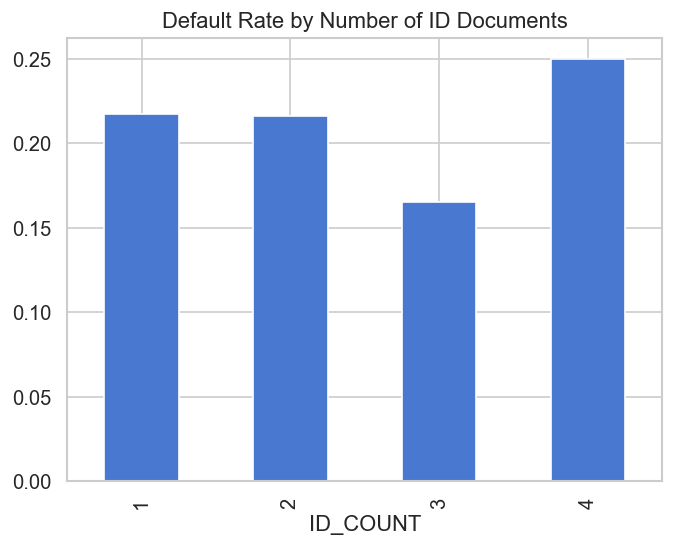

In [131]:
# แปลงให้เป็น binary ก่อนแล้วค่อย sum
df['ID_COUNT'] = df[id_flags].apply(lambda x: (x == 1).astype(int)).sum(axis=1)

print(df['ID_COUNT'].value_counts().sort_index())
# ควรเห็นค่าตั้งแต่ 0 ถึง 5

# จากนั้น plot default rate ต่อ ID_COUNT
df.groupby('ID_COUNT')['LOAN_DEFAULT'].mean().plot(
    kind='bar', title='Default Rate by Number of ID Documents'
)

In [133]:
from statsmodels.stats.proportion import proportion_confint

results = []
for count in sorted(df['ID_COUNT'].unique()):
    subset = df[df['ID_COUNT'] == count]['LOAN_DEFAULT']
    n = len(subset)
    defaults = subset.sum()
    rate = defaults / n
    
    # Wilson confidence interval เหมาะกับ proportion มากกว่า normal approximation
    lower, upper = proportion_confint(defaults, n, alpha=0.05, method='wilson')
    
    results.append({
        'ID_COUNT': count, 'n': n,
        'default_rate': rate,
        'CI_lower': lower, 'CI_upper': upper
    })

result_df = pd.DataFrame(results)
print(result_df.round(3))

   ID_COUNT       n  default_rate  CI_lower  CI_upper
0         1  213389         0.217     0.215     0.219
1         2   19434         0.216     0.210     0.222
2         3     327         0.165     0.129     0.209
3         4       4         0.250     0.046     0.699


In [135]:
# มี identity document เพิ่มเติมนอกจาก AADHAR ไหม?
df['HAS_EXTRA_ID'] = (df['ID_COUNT'] > 1).astype(int)
print(df.groupby('HAS_EXTRA_ID')['LOAN_DEFAULT'].mean())

HAS_EXTRA_ID
0    0.217228
1    0.215381
Name: LOAN_DEFAULT, dtype: float64


In [136]:
# ตรวจสอบค่าผิดปกติก่อน log transform
problem_cols = ['PRI_CURRENT_BALANCE', 'DISBURSED_AMOUNT']

for col in problem_cols:
    print(f"\n{col}:")
    print(f"  มีค่าติดลบ: {(df[col] < 0).sum()} rows")
    print(f"  มีค่าเป็น 0: {(df[col] == 0).sum()} rows")
    print(f"  min value: {df[col].min():.4f}")
    print(f"  describe:\n{df[col].describe()}")


PRI_CURRENT_BALANCE:
  มีค่าติดลบ: 448 rows
  มีค่าเป็น 0: 141696 rows
  min value: -6678296.0000
  describe:
count    2.331540e+05
mean     1.659001e+05
std      9.422736e+05
min     -6.678296e+06
25%      0.000000e+00
50%      0.000000e+00
75%      3.500650e+04
max      9.652492e+07
Name: PRI_CURRENT_BALANCE, dtype: float64

DISBURSED_AMOUNT:
  มีค่าติดลบ: 0 rows
  มีค่าเป็น 0: 0 rows
  min value: 13320.0000
  describe:
count    233154.000000
mean      54356.993528
std       12971.314171
min       13320.000000
25%       47145.000000
50%       53803.000000
75%       60413.000000
max      990572.000000
Name: DISBURSED_AMOUNT, dtype: float64


In [137]:
import numpy as np

# สร้าง flag ก่อนเพื่อเก็บ "ความหมาย" ของ zero ไว้
df['HAS_PRI_BALANCE'] = (df['PRI_CURRENT_BALANCE'] > 0).astype(int)

# ตรวจสอบว่า flag นี้มี signal ไหม
print(df.groupby('HAS_PRI_BALANCE')['LOAN_DEFAULT'].mean())
# ถ้าต่างกันชัด → feature นี้มีคุณค่าสูงมาก

# จากนั้นค่อย log transform โดย clamp ค่าติดลบไว้ที่ 0
df['PRI_CURRENT_BALANCE_LOG'] = np.log1p(df['PRI_CURRENT_BALANCE'].clip(lower=0))

HAS_PRI_BALANCE
0    0.22544
1    0.20400
Name: LOAN_DEFAULT, dtype: float64


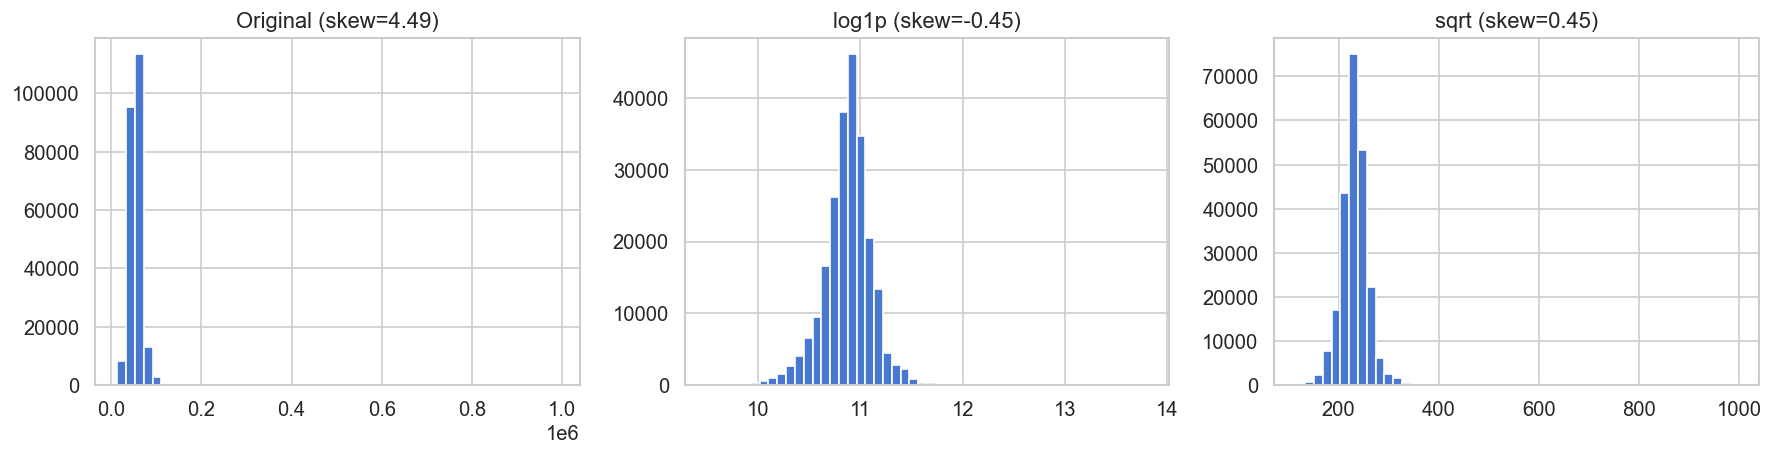

In [138]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original
df['DISBURSED_AMOUNT'].hist(bins=50, ax=axes[0])
axes[0].set_title(f'Original (skew={df["DISBURSED_AMOUNT"].skew():.2f})')

# Log1p
np.log1p(df['DISBURSED_AMOUNT']).hist(bins=50, ax=axes[1])
axes[1].set_title(f'log1p (skew={np.log1p(df["DISBURSED_AMOUNT"]).skew():.2f})')

# Square root — อีก option ที่ mild กว่า log
np.sqrt(df['DISBURSED_AMOUNT']).hist(bins=50, ax=axes[2])
axes[2].set_title(f'sqrt (skew={np.sqrt(df["DISBURSED_AMOUNT"]).skew():.2f})')

plt.tight_layout()

In [141]:
# df["AVERAGE_ACCT_AGE_MON"]    = df["AVERAGE_ACCT_AGE"].apply(parse_months)
# df["CREDIT_HISTORY_LEN_MON"]  = df["CREDIT_HISTORY_LENGTH"].apply(parse_months)
df[["AVERAGE_ACCT_AGE_MON","CREDIT_HISTORY_LEN_MON"]]

,AVERAGE_ACCT_AGE_MON,CREDIT_HISTORY_LEN_MON
0,0,0
1,23,23
2,0,0
3,8,15
4,0,0
...,...,...
233149,21,39
233150,6,6
233151,0,0
233152,0,0


In [142]:
# ตรวจสอบความถูกต้องของการ parse โดยดู sample เปรียบเทียบ
check_cols = ["AVERAGE_ACCT_AGE", "AVERAGE_ACCT_AGE_MON",
              "CREDIT_HISTORY_LENGTH", "CREDIT_HISTORY_LEN_MON"]

# ดู rows ที่ค่าไม่เป็น 0 เพื่อ verify ว่า parse ถูก
print(df[check_cols][df["AVERAGE_ACCT_AGE_MON"] > 0].head(10))

# ตรวจสอบ distribution หลัง parse
print(df[["AVERAGE_ACCT_AGE_MON", "CREDIT_HISTORY_LEN_MON"]].describe())

# นับว่ามีค่า 0 กี่ row
print(f"\nAVERAGE_ACCT_AGE_MON = 0: {(df['AVERAGE_ACCT_AGE_MON'] == 0).sum():,} rows")
print(f"CREDIT_HISTORY_LEN_MON = 0: {(df['CREDIT_HISTORY_LEN_MON'] == 0).sum():,} rows")

   AVERAGE_ACCT_AGE  AVERAGE_ACCT_AGE_MON CREDIT_HISTORY_LENGTH  \
1        1yrs 11mon                    23            1yrs 11mon   
3         0yrs 8mon                     8             1yrs 3mon   
5         1yrs 9mon                    21             2yrs 0mon   
7         0yrs 2mon                     2             0yrs 2mon   
8         4yrs 8mon                    56             4yrs 8mon   
9         1yrs 7mon                    19             1yrs 7mon   
10        0yrs 7mon                     7             0yrs 7mon   
11        2yrs 1mon                    25             2yrs 3mon   
12        1yrs 3mon                    15             2yrs 9mon   
13        1yrs 0mon                    12             2yrs 1mon   

    CREDIT_HISTORY_LEN_MON  
1                       23  
3                       15  
5                       24  
7                        2  
8                       56  
9                       19  
10                       7  
11                      27  
1

In [143]:
# สร้าง flag ว่า "มีประวัติเครดิตหรือไม่"
df["HAS_CREDIT_HISTORY"] = (df["AVERAGE_ACCT_AGE_MON"] > 0).astype(int)

# ตรวจสอบว่า flag นี้มี signal ไหม
print("Default rate by HAS_CREDIT_HISTORY:")
print(df.groupby("HAS_CREDIT_HISTORY")["LOAN_DEFAULT"].mean())

# คาดว่า HAS_CREDIT_HISTORY = 0 จะมี default rate สูงกว่า
# เพราะ "thin file" มักถือว่า riskier ใน credit scoring

Default rate by HAS_CREDIT_HISTORY:
HAS_CREDIT_HISTORY
0    0.231686
1    0.201738
Name: LOAN_DEFAULT, dtype: float64


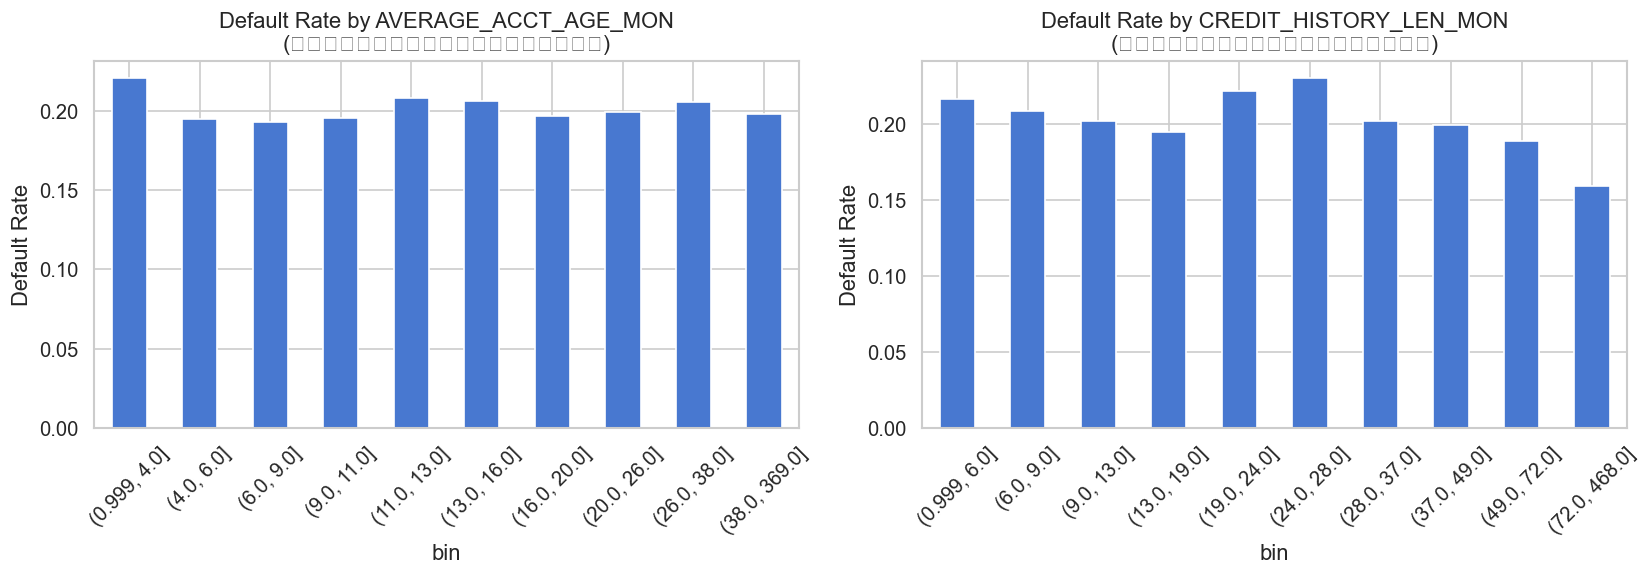

In [144]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["AVERAGE_ACCT_AGE_MON", "CREDIT_HISTORY_LEN_MON"]):
    # แบ่งเป็น bins แล้วดู default rate ต่อ bin
    # ใช้เฉพาะ rows ที่มีประวัติ (> 0) เพื่อดู trend ที่แท้จริง
    has_history = df[df[col] > 0].copy()
    has_history["bin"] = pd.qcut(has_history[col], q=10, duplicates="drop")
    
    default_by_bin = has_history.groupby("bin")["LOAN_DEFAULT"].mean()
    default_by_bin.plot(kind="bar", ax=ax, rot=45)
    ax.set_title(f"Default Rate by {col}\n(เฉพาะคนที่มีประวัติ)")
    ax.set_ylabel("Default Rate")

plt.tight_layout()

In [145]:
# สรุป features ที่สร้างจากสองตัวนี้

# 1. Binary flag — signal ชัดเจนที่สุด (3% difference)
df["HAS_CREDIT_HISTORY"] = (df["AVERAGE_ACCT_AGE_MON"] > 0).astype(int)

# 2. ค่า months แบบ numeric — เก็บไว้ให้ model ลองใช้
#    แต่เนื่องจาก 50% เป็น 0 อาจต้อง handle ด้วย log1p
#    log1p(0) = 0 ซึ่ง ok เพราะ 0 ยังคงหมายถึง "ไม่มีประวัติ" เหมือนเดิม
df["AVERAGE_ACCT_AGE_MON_LOG"]    = np.log1p(df["AVERAGE_ACCT_AGE_MON"])
df["CREDIT_HISTORY_LEN_MON_LOG"]  = np.log1p(df["CREDIT_HISTORY_LEN_MON"])

## Preprocessing Pipeline

In [146]:
from sklearn.model_selection import train_test_split

# แยก features และ target ออกจากกันก่อน
X = df.drop(columns=["LOAN_DEFAULT"])
y = df["LOAN_DEFAULT"]

# Split 80/20 และใช้ stratify=y เพราะ dataset มี class imbalance
# stratify ทำให้สัดส่วน 0/1 ใน train และ test เท่ากัน
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Test default rate:  {y_test.mean():.3f}")
# ถ้า stratify ทำงานถูกต้อง สองค่านี้ควรเกือบเท่ากัน

Train: (186523, 61), Test: (46631, 61)
Train default rate: 0.217
Test default rate:  0.217


In [147]:
# Columns ที่ตัดสินใจ drop จาก EDA
drop_cols = [
    "MOBILENO_AVL_FLAG",      # zero variance
    "UNIQUEID",               # identifier ไม่มี predictive power
    "AVERAGE_ACCT_AGE",       # ใช้ _MON แทนแล้ว
    "CREDIT_HISTORY_LENGTH",  # ใช้ _MON แทนแล้ว
    # Multicollinearity: เก็บ DISBURSED ทิ้ง SANCTIONED
    # เพราะ disbursed = จำนวนที่จ่ายจริง มีความหมายมากกว่า
    "PRI_SANCTIONED_AMOUNT",
    "SEC_SANCTIONED_AMOUNT",
]

X_train = X_train.drop(columns=drop_cols)
X_test  = X_test.drop(columns=drop_cols)

In [149]:
# Categorical columns ที่ต้อง encode
cat_cols = ["EMPLOYMENT_TYPE", "PERFORM_CNS_SCORE_DESCRIPTION"]

# ID-like columns ที่ควรทำ target encoding (cardinality สูง)
high_cardinality_cols = ["BRANCH_ID", "SUPPLIER_ID", "MANUFACTURER_ID",
                          "CURRENT_PINCODE_ID", "STATE_ID", "EMPLOYEE_CODE_ID"]

# Binary columns ที่เป็น 0/1 อยู่แล้ว — ไม่ต้องทำอะไร
binary_cols = ["AADHAR_FLAG", "PAN_FLAG", "VOTERID_FLAG", "DRIVING_FLAG",
               "PASSPORT_FLAG", "HAS_CREDIT_HISTORY", "HAS_PRI_BALANCE",
               "AGE_AT_DISBURSAL_CLUSTER"]

# Numerical columns ที่ต้อง scale
# รวมทั้ง original และ derived features ที่สร้างไว้
num_cols = ["DISBURSED_AMOUNT", "ASSET_COST", "LTV", "PERFORM_CNS_SCORE",
            "PRI_NO_OF_ACCTS", "PRI_ACTIVE_ACCTS", "PRI_OVERDUE_ACCTS",
            "PRI_CURRENT_BALANCE", "PRI_DISBURSED_AMOUNT",
            "SEC_NO_OF_ACCTS", "SEC_ACTIVE_ACCTS", "SEC_OVERDUE_ACCTS",
            "SEC_CURRENT_BALANCE", "SEC_DISBURSED_AMOUNT",
            "PRIMARY_INSTAL_AMT", "SEC_INSTAL_AMT",
            "NEW_ACCTS_IN_LAST_SIX_MONTHS", "DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS",
            "NO_OF_INQUIRIES", "AVERAGE_ACCT_AGE_MON", "CREDIT_HISTORY_LEN_MON",
            "AGE_AT_DISBURSAL", "PRI_OVERDUE_RATIO", "PRI_ACTIVE_RATIO"]

In [151]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [153]:
# สำหรับ PERFORM_CNS_SCORE_DESCRIPTION ใช้ ordinal ที่ map ไว้แล้วจาก EDA
cns_risk_map = {
    "M-Very High Risk": 13, "L-Very High Risk": 12, "K-High Risk": 11,
    "J-High Risk": 10, "I-Medium Risk": 9, "H-Medium Risk": 8,
    "No Bureau History Available": 8,
    "Not Scored: Sufficient History Not Available": 9,
    "Not Scored: Not Enough Info available on the customer": 7,
    "Not Scored: No Updates available in last 36 months": 6,
    "Not Scored: No Activity seen on the customer (Inactive)": 5,
    "Not Scored: Only a Guarantor": 5,
    "G-Low Risk": 7, "F-Low Risk": 6, "E-Low Risk": 5,
    "D-Very Low Risk": 4, "C-Very Low Risk": 3,
    "B-Very Low Risk": 2, "A-Very Low Risk": 1,
    "Not Scored: More than 50 active Accounts found": 3,
}

# ใช้ .get() หรือตรวจสอบคอลัมน์ก่อน map เพื่อความปลอดภัย
if "PERFORM_CNS_SCORE_DESCRIPTION" in X_train.columns:
    X_train["CNS_RISK_ORDINAL"] = X_train["PERFORM_CNS_SCORE_DESCRIPTION"].map(cns_risk_map)
if "PERFORM_CNS_SCORE_DESCRIPTION" in X_test.columns:
    X_test["CNS_RISK_ORDINAL"]  = X_test["PERFORM_CNS_SCORE_DESCRIPTION"].map(cns_risk_map)

# One-hot สำหรับ EMPLOYMENT_TYPE (ตรวจสอบก่อนว่ามีคอลัมน์อยู่ไหม)
if "EMPLOYMENT_TYPE" in X_train.columns:
    X_train = pd.get_dummies(X_train, columns=["EMPLOYMENT_TYPE"], drop_first=True)
if "EMPLOYMENT_TYPE" in X_test.columns:
    X_test  = pd.get_dummies(X_test,  columns=["EMPLOYMENT_TYPE"], drop_first=True)

# Target Encoding สำหรับ high cardinality cols
from category_encoders import TargetEncoder

# กรองเฉพาะคอลัมน์ที่มีอยู่ใน DataFrame จริงๆ เท่านั้น
valid_target_cols = [c for c in high_cardinality_cols if c in X_train.columns]

if valid_target_cols:
    te = TargetEncoder(cols=valid_target_cols, smoothing=10)
    X_train[valid_target_cols] = te.fit_transform(X_train[valid_target_cols], y_train)
    X_test[valid_target_cols] = te.transform(X_test[valid_target_cols])

# Drop original CNS description column หลังจาก encode แล้ว (ถ้ายังมีอยู่)
cols_to_drop = ["PERFORM_CNS_SCORE_DESCRIPTION"]
X_train = X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns])
X_test  = X_test.drop(columns=[c for c in cols_to_drop if c in X_test.columns])


In [154]:
from sklearn.preprocessing import RobustScaler

# RobustScaler เหมาะกว่า StandardScaler สำหรับข้อมูลที่มี outlier เยอะ
# เพราะใช้ median และ IQR แทน mean และ std
# ทำให้ outlier ที่เหลืออยู่ไม่สามารถ "ดึง" scale ไปได้

scaler = RobustScaler()

# fit ONLY บน train data แล้วค่อย transform ทั้งคู่
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test[num_cols])

In [155]:
# ตัวอย่างสำหรับ XGBoost
# คำนวณ scale_pos_weight = จำนวน negative / จำนวน positive
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"scale_pos_weight = {scale_pos_weight:.2f}")
# ค่านี้จะบอก XGBoost ว่าให้ "ให้น้ำหนัก" กับ positive class มากขึ้น
# เช่น ถ้าได้ ~3.5 หมายความว่า 1 ตัวอย่าง default มีค่าเท่ากับ 3.5 ตัวอย่าง non-default

scale_pos_weight = 3.61


In [157]:
pip install imblearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [imblearn]1/3 [imbalanced-learn]
Note: you may need to restart the kernel to use updated packages.


In [159]:
from imblearn.over_sampling import SMOTE

# CRITICAL: ทำ SMOTE เฉพาะบน training data เท่านั้น!
# ถ้าทำบน test data ด้วย จะเป็น data leakage ที่ร้ายแรงมาก
# เพราะ test set ควรสะท้อน "โลกจริง" ไม่ใช่ข้อมูลสังเคราะห์


# กรองเอาเฉพาะ numeric columns ก่อนทำ SMOTE
# เพราะ SMOTE ต้องการการคำนวณทางคณิตศาสตร์ (Interpolation) ที่ใช้ได้กับตัวเลขเท่านั้น
X_train_numeric = X_train.select_dtypes(include=['number', 'bool'])

# ทำ SMOTE เฉพาะบนข้อมูลที่เป็นตัวเลข
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_numeric, y_train)

print(f"Original shape: {X_train.shape}")
print(f"Resampled shape: {X_train_resampled.shape}")
print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_resampled).value_counts().to_dict()}")


Original shape: (186523, 55)
Resampled shape: (292068, 53)
Before SMOTE: {0: 146034, 1: 40489}
After SMOTE:  {1: 146034, 0: 146034}


In [163]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# แนวทางที่แนะนำ: ทดลองเปรียบเทียบทั้งสามวิธี
# แล้ววัดด้วย AUC-ROC และ F1 บน test set จริงๆ

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

# วิธีที่ 1: ไม่ทำอะไรเลย (baseline)
model_baseline = XGBClassifier(random_state=42)

# วิธีที่ 2: scale_pos_weight (แนะนำสำหรับ XGBoost)
model_weighted = XGBClassifier(
    scale_pos_weight=neg/pos,  # ~3.5 สำหรับ dataset นี้
    random_state=42
)

# วิธีที่ 3: SMOTE (ถ้าอยากลอง)
# ใช้ X_train_resampled, y_train_resampled แทน

# วัดผลด้วย metric ที่เหมาะสม
from sklearn.metrics import roc_auc_score, f1_score, classification_report

for name, model, X_tr, y_tr in [
    ("Baseline",       model_baseline, X_train,           y_train),
    ("Weighted",       model_weighted, X_train,           y_train),
    ("SMOTE",          model_baseline, X_train_resampled, y_train_resampled),
]:
    model.fit(X_tr, y_tr)
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*40}")
    print(f"Method: {name}")
    print(f"AUC-ROC : {roc_auc_score(y_test, y_pred_prob):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:DATE_OF_BIRTH: datetime64[us], DISBURSAL_DATE: datetime64[us]

In [162]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# 1. เตรียมข้อมูลให้พร้อม (เอาเฉพาะตัวเลข/Boolean) เพื่อป้องกัน DTypePromotionError
# ทำทั้ง Train และ Test ให้มีคอลัมน์เหมือนกัน
X_train_fin = X_train.select_dtypes(include=['number', 'bool'])
X_test_fin  = X_test.select_dtypes(include=['number', 'bool'])

# 2. คำนวณน้ำหนักสำหรับวิธี Weighted
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos

# 3. เตรียม SMOTE (ใช้ X_train_fin ที่กรองแล้ว)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_fin, y_train)

# 4. สร้าง Model วัตถุประสงค์ต่างๆ
model_baseline = XGBClassifier(random_state=42)
model_weighted = XGBClassifier(scale_pos_weight=ratio, random_state=42)

# 5. เปรียบเทียบผลลัพธ์
for name, model, X_tr, y_tr in [
    ("Baseline",       model_baseline, X_train_fin,       y_train),
    ("Weighted",       model_weighted, X_train_fin,       y_train),
    ("SMOTE",          model_baseline, X_train_resampled, y_train_resampled),
]:
    model.fit(X_tr, y_tr)
    
    # ตอน Predict ต้องใช้ X_test_fin ที่มีคอลัมน์เหมือนกับตอน Fit
    y_pred      = model.predict(X_test_fin)
    y_pred_prob = model.predict_proba(X_test_fin)[:, 1]
    
    print(f"\n{'='*40}")
    print(f"Method: {name}")
    print(f"AUC-ROC : {roc_auc_score(y_test, y_pred_prob):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))


XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/ratchanon.pan/vehicle-loan-default-prediction/.venv/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Users/ratchanon.pan/vehicle-loan-default-prediction/.venv/lib/python3.11/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Pre

In [164]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE

# 1. คลีนข้อมูล: เอาเฉพาะตัวเลขและ Boolean (ตัดคอลัมน์วันที่ออก)
# เราจะใช้ X_train_fin และ X_test_fin เป็นตัวหลักในการทดลองทุกวิธี
X_train_fin = X_train.select_dtypes(include=['number', 'bool'])
X_test_fin  = X_test.select_dtypes(include=['number', 'bool'])

# 2. เตรียมข้อมูล SMOTE จากชุดที่คลีนแล้ว
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_fin, y_train)

# 3. คำนวณน้ำหนักสำหรับวิธี Weighted
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
ratio = neg / pos

# 4. สร้าง Model
model_baseline = XGBClassifier(random_state=42)
model_weighted = XGBClassifier(scale_pos_weight=ratio, random_state=42)

# 5. เปรียบเทียบทั้ง 3 วิธี
# สังเกตว่าตอนนี้ทุกวิธีจะใช้ Features ชุดเดียวกัน (ที่เป็นตัวเลขทั้งหมด)
for name, model, X_tr, y_tr in [
    ("Baseline",       model_baseline, X_train_fin,       y_train),
    ("Weighted",       model_weighted, X_train_fin,       y_train),
    ("SMOTE",          model_baseline, X_train_resampled, y_train_resampled),
]:
    # เทรน Model
    model.fit(X_tr, y_tr)
    
    # พยากรณ์บน Test Set โดยใช้ X_test_fin (ที่มีคอลัมน์ตรงกับตอนเทรน)
    y_pred      = model.predict(X_test_fin)
    y_pred_prob = model.predict_proba(X_test_fin)[:, 1]
    
    print(f"\n{'='*40}")
    print(f"Method: {name}")
    print(f"AUC-ROC : {roc_auc_score(y_test, y_pred_prob):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))



Method: Baseline
AUC-ROC : 0.6532
F1 Score: 0.1368
              precision    recall  f1-score   support

           0       0.79      0.97      0.87     36509
           1       0.43      0.08      0.14     10122

    accuracy                           0.78     46631
   macro avg       0.61      0.53      0.50     46631
weighted avg       0.71      0.78      0.71     46631


Method: Weighted
AUC-ROC : 0.6500
F1 Score: 0.4002
              precision    recall  f1-score   support

           0       0.84      0.64      0.73     36509
           1       0.31      0.58      0.40     10122

    accuracy                           0.62     46631
   macro avg       0.58      0.61      0.56     46631
weighted avg       0.73      0.62      0.66     46631


Method: SMOTE
AUC-ROC : 0.6487
F1 Score: 0.2027
              precision    recall  f1-score   support

           0       0.80      0.95      0.87     36509
           1       0.41      0.13      0.20     10122

    accuracy                 

In [166]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report
import pandas as pd

# strategy='most_frequent' คือเดา class 0 ตลอดเวลา
# เป็น worst-case baseline ที่ทุก model ต้องทำได้ดีกว่า
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)
y_prob_dummy = dummy.predict_proba(X_test)[:, 1]

print("=== Dummy Classifier ===")
print(classification_report(y_test, y_pred_dummy))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_dummy):.4f}")
# AUC-ROC ของ Dummy จะได้ 0.5 เสมอ เพราะมันเดาแบบสุ่มจากมุมมองของ ranking

=== Dummy Classifier ===
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     36509
           1       0.00      0.00      0.00     10122

    accuracy                           0.78     46631
   macro avg       0.39      0.50      0.44     46631
weighted avg       0.61      0.78      0.69     46631

AUC-ROC: 0.5000


In [168]:
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# 1. กรองเฉพาะคอลัมน์ที่เป็นตัวเลข/Boolean เท่านั้น (ตัด Datetime ออก)
X_train_fin = X_train.select_dtypes(include=['number', 'bool'])
X_test_fin  = X_test.select_dtypes(include=['number', 'bool'])

# 2. ทำ Scaling (เพราะ Logistic Regression ต้องการข้อมูลที่ Scale แล้ว)
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_fin), 
    columns=X_train_fin.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_fin), 
    columns=X_test_fin.columns
)

# 3. เทรน Model
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

# 4. พยากรณ์
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.4f}")

# 5. ดู coefficient เพื่อดูว่าตัวแปรไหนมีผลต่อการเบี้ยวหนี้ (Default)
coef_df = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "coefficient": lr.coef_[0]
}).sort_values("coefficient", ascending=False)

print("\nTop features pushing toward DEFAULT (positive coef):")
print(coef_df.head(5))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.84      0.64      0.73     36509
           1       0.31      0.57      0.40     10122

    accuracy                           0.63     46631
   macro avg       0.58      0.61      0.57     46631
weighted avg       0.73      0.63      0.66     46631

AUC-ROC: 0.6522

Top features pushing toward DEFAULT (positive coef):
               feature  coefficient
6   CURRENT_PINCODE_ID     0.341754
8     EMPLOYEE_CODE_ID     0.300706
4          SUPPLIER_ID     0.257039
2                  LTV     0.228909
51    CNS_RISK_ORDINAL     0.198470


In [169]:
from xgboost import XGBClassifier

# คำนวณ scale_pos_weight จาก training data
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos  # ประมาณ 3.5 สำหรับ dataset นี้

xgb = XGBClassifier(
    # --- Class imbalance ---
    scale_pos_weight=spw,

    # --- Hyperparameters เริ่มต้น (ยังไม่ tune) ---
    n_estimators=300,       # จำนวน trees ที่สร้าง
    learning_rate=0.05,     # ขนาดก้าวในการ update แต่ละรอบ
                            # ค่าเล็ก → เรียนรู้ช้า แต่ generalize ดีกว่า
    max_depth=6,            # ความลึกสูงสุดของแต่ละ tree
                            # ถ้าลึกเกินไป → overfit ได้ง่าย
    subsample=0.8,          # ใช้ข้อมูล 80% ในการสร้างแต่ละ tree
                            # ช่วยลด overfitting
    colsample_bytree=0.8,   # ใช้ feature 80% ในแต่ละ tree
                            # ช่วยให้ trees หลากหลายขึ้น

    # --- อื่นๆ ---
    eval_metric="auc",      # ใช้ AUC เป็น metric ในการ monitor
    random_state=42,
    n_jobs=-1               # ใช้ทุก CPU core ที่มี
)

# early_stopping_rounds ป้องกัน overfitting
# ถ้า AUC บน validation set ไม่ดีขึ้นใน 50 รอบ → หยุด
xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=50,
    verbose=100  # print progress ทุก 100 rounds
)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

TypeError: XGBClassifier.fit() got an unexpected keyword argument 'early_stopping_rounds'

In [172]:
from xgboost import XGBClassifier

# 1. กรองเฉพาะคอลัมน์ตัวเลขเหมือนเดิมเพื่อความปลอดภัย
X_train_fin = X_train.select_dtypes(include=['number', 'bool'])
X_test_fin  = X_test.select_dtypes(include=['number', 'bool'])

# คำนวณ scale_pos_weight จาก training data
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos  # ประมาณ 3.5 สำหรับ dataset นี้

# 2. ย้าย early_stopping_rounds มาไว้ใน Constructor
xgb = XGBClassifier(
    scale_pos_weight=spw,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    early_stopping_rounds=50,  # <--- ย้ายมาไว้ตรงนี้ครับ
    random_state=42,
    n_jobs=-1
)

# 3. รัน fit โดยเหลือแค่ eval_set
xgb.fit(
    X_train_fin, y_train,
    eval_set=[(X_test_fin, y_test)], # ใช้ข้อมูลที่คลีนแล้ว
    verbose=100
)

# 4. พยากรณ์
y_pred_xgb = xgb.predict(X_test_fin)
y_prob_xgb = xgb.predict_proba(X_test_fin)[:, 1]

print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_xgb):.4f}")


[0]	validation_0-logloss:0.68906
[100]	validation_0-logloss:0.64243
[200]	validation_0-logloss:0.63996
[300]	validation_0-logloss:0.63836
[400]	validation_0-logloss:0.63702
[500]	validation_0-logloss:0.63581
[600]	validation_0-logloss:0.63461
[700]	validation_0-logloss:0.63336
[800]	validation_0-logloss:0.63245
[900]	validation_0-logloss:0.63162
[999]	validation_0-logloss:0.63056

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.84      0.65      0.73     36509
           1       0.31      0.56      0.40     10122

    accuracy                           0.63     46631
   macro avg       0.58      0.61      0.57     46631
weighted avg       0.73      0.63      0.66     46631

AUC-ROC: 0.6519


In [173]:
results = {
    "Dummy":               (y_pred_dummy, y_prob_dummy),
    "Logistic Regression": (y_pred_lr,    y_prob_lr),
    "XGBoost":             (y_pred_xgb,   y_prob_xgb),
}

summary = []
for name, (y_pred, y_prob) in results.items():
    from sklearn.metrics import precision_score, recall_score
    summary.append({
        "Model":     name,
        "AUC-ROC":   round(roc_auc_score(y_test, y_prob), 4),
        "F1":        round(f1_score(y_test, y_pred), 4),
        # Recall ของ class 1 สำคัญมากสำหรับ loan default
        # เพราะเราอยากจับ default ให้ได้มากที่สุด
        "Recall@1":  round(recall_score(y_test, y_pred), 4),
        "Precision@1": round(precision_score(y_test, y_pred), 4),
    })

print(pd.DataFrame(summary).to_string(index=False))

              Model  AUC-ROC     F1  Recall@1  Precision@1
              Dummy   0.5000 0.0000    0.0000       0.0000
Logistic Regression   0.6522 0.4008    0.5715       0.3086
            XGBoost   0.6519 0.3984    0.5619       0.3086


<Figure size 1200x960 with 0 Axes>

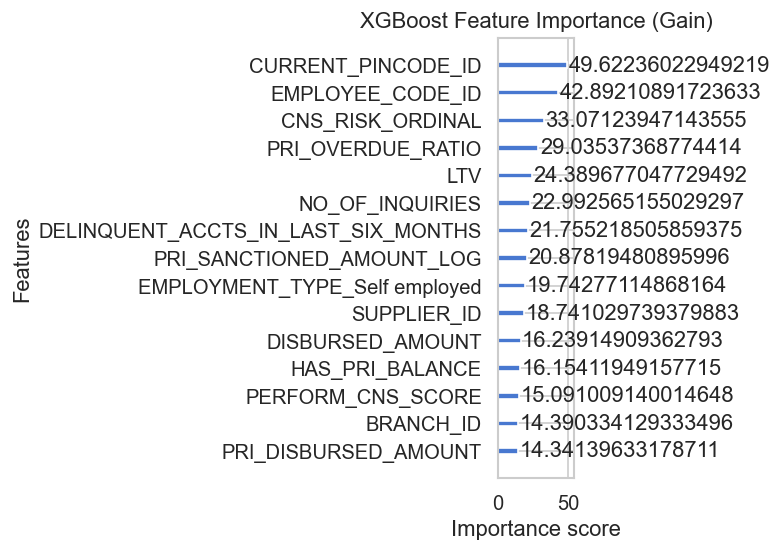

In [174]:
import matplotlib.pyplot as plt

# plot_importance แบบ 'gain' ดีกว่า 'weight' เพราะวัดว่า
# feature นั้นช่วยลด impurity ได้เท่าไหร่ ไม่ใช่แค่ถูกใช้กี่ครั้ง
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(xgb, importance_type="gain", max_num_features=15)
plt.title("XGBoost Feature Importance (Gain)")
plt.tight_layout()
plt.show()

In [176]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 12.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [optuna]2m5/6 [optuna]]my]
Note: you may need to restart the kernel to use updated packages.


In [177]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ปิด log ของ optuna ที่ verbose เกินไป
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """
    ฟังก์ชันนี้คือ 'สูตรการทดลอง' ที่ Optuna จะเรียกซ้ำๆ
    แต่ละครั้ง trial จะ suggest ค่า hyperparameter ชุดใหม่
    แล้วเราวัดผลด้วย cross-validation และ return ค่า AUC กลับไป
    Optuna จะเรียนรู้จาก AUC ที่ได้แต่ละรอบ เพื่อ suggest ค่าที่ดีขึ้นในรอบถัดไป
    """
    params = {
        "scale_pos_weight": spw,
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1,

        # --- Parameters ที่ Optuna จะ tune ---
        # suggest_int → สุ่มจาก integer range
        # suggest_float → สุ่มจาก float range
        # log=True → สุ่มใน log scale เหมาะกับค่าที่มี range กว้างมาก
        #             เช่น 0.001 ถึง 0.3 ถ้าสุ่ม linear จะได้ค่าใหญ่บ่อยกว่า

        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 9),

        # min_child_weight สูงช่วยลด overfitting บน imbalanced data
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),

        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),

        # Regularization — ค่า 0 หมายถึงไม่มี regularization เลย
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),

        # gamma คือ minimum loss reduction ที่ยอมให้ tree แตกกิ่ง
        # ค่าสูง → tree จะแตกกิ่งน้อยลง → simple model
        "gamma": trial.suggest_float("gamma", 0, 5),
    }

    model = XGBClassifier(**params)

    # ใช้ StratifiedKFold เพราะ dataset มี class imbalance
    # stratified = แต่ละ fold มีสัดส่วน default/non-default เท่ากัน
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # cross_val_score จะ train 5 รอบและ return AUC ของแต่ละ fold
    auc_scores = cross_val_score(
        model, X_train_fin, y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    # return ค่าเฉลี่ย AUC ทั้ง 5 folds
    # Optuna จะพยายาม maximize ค่านี้
    return auc_scores.mean()


# สร้าง study object — นี่คือ "สมุดบันทึก" ที่เก็บผลการทดลองทุกรอบ
# direction="maximize" บอกว่าเราต้องการ AUC สูงที่สุด
study = optuna.create_study(
    direction="maximize",
    # TPESampler คือ Bayesian algorithm ที่ Optuna ใช้
    sampler=optuna.samplers.TPESampler(seed=42)
)

# เริ่ม optimize — n_trials คือจำนวนรอบที่ทดลอง
# 50 รอบเป็นจุดเริ่มต้นที่ดีครับ ถ้าเวลาเยอะลอง 100
print("Starting Optuna optimization...")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

Starting Optuna optimization...


Best trial: 48. Best value: 0.716208: 100%|██████████| 50/50 [06:37<00:00,  7.95s/it]


Best AUC: 0.7162
Best params: {'n_estimators': 371, 'learning_rate': 0.030940036947813814, 'max_depth': 7, 'min_child_weight': 12, 'subsample': 0.7282298851311918, 'colsample_bytree': 0.5303377215216092, 'reg_alpha': 3.642607685116315, 'reg_lambda': 8.457033310545672, 'gamma': 4.046710607938849}


In [178]:
# ดึง best params มาใช้ train บน training data ทั้งหมด
best_params = study.best_params
best_params.update({
    "scale_pos_weight": spw,
    "eval_metric": "logloss",
    "random_state": 42,
    "n_jobs": -1,
    "early_stopping_rounds": 50,  # ป้องกัน overfit เพิ่มเติม
})

xgb_tuned = XGBClassifier(**best_params)
xgb_tuned.fit(
    X_train_fin, y_train,
    eval_set=[(X_test_fin, y_test)],
    verbose=100
)

# เปรียบเทียบผลก่อนและหลัง tune
y_prob_tuned = xgb_tuned.predict_proba(X_test_fin)[:, 1]
y_pred_tuned = xgb_tuned.predict(X_test_fin)

print(f"Before tuning — AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"After tuning  — AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(classification_report(y_test, y_pred_tuned))

[0]	validation_0-logloss:0.69073
[100]	validation_0-logloss:0.64134
[200]	validation_0-logloss:0.63901
[300]	validation_0-logloss:0.63759
[370]	validation_0-logloss:0.63671
Before tuning — AUC: 0.6519
After tuning  — AUC: 0.6585
              precision    recall  f1-score   support

           0       0.85      0.63      0.73     36509
           1       0.31      0.59      0.41     10122

    accuracy                           0.62     46631
   macro avg       0.58      0.61      0.57     46631
weighted avg       0.73      0.62      0.66     46631



In [180]:
pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 12.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]
Note: you may need to restart the kernel to use updated packages.


In [183]:
# ต้องติดตั้ง plotly ก่อน: pip install plotly
import optuna.visualization as vis

# 1. Optimization history — AUC ดีขึ้นอย่างไรตามจำนวน trials
#    ถ้า curve ยังลงอยู่เรื่อยๆ แสดงว่าควรเพิ่ม n_trials
vis.plot_optimization_history(study).show()

# 2. Parameter importance — parameter ไหนมีผลต่อ AUC มากที่สุด?
#    ถ้า learning_rate สำคัญที่สุด → ควร tune ตัวนี้ละเอียดขึ้น
vis.plot_param_importances(study).show()

# 3. Contour plot — ดูความสัมพันธ์ระหว่าง 2 parameters
#    เช่น max_depth กับ learning_rate interact กันอย่างไร?
vis.plot_contour(study, params=["max_depth", "learning_rate"]).show()

ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.

In [185]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 11.1 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [catboost]1/2 [catboost]
Note: you may need to restart the kernel to use updated packages.


In [186]:
import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

# --- Objective สำหรับ LightGBM ---
def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        # num_leaves สำคัญมากสำหรับ LightGBM
        # เพราะมันใช้ leaf-wise growth ค่าสูงหมายถึง tree ซับซ้อนขึ้น
        # rule of thumb: num_leaves < 2^max_depth เพื่อป้องกัน overfit
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        # จัดการ class imbalance แบบเดียวกับ XGBoost
        "scale_pos_weight": spw,
        "random_state": 42,
        "n_jobs": -1,
        "verbose": -1,  # ปิด log ระหว่าง training
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        LGBMClassifier(**params),
        X_train_fin, y_train,
        cv=cv, scoring="roc_auc", n_jobs=-1
    )
    return scores.mean()


# --- Objective สำหรับ CatBoost ---
# CatBoost ต้องการ categorical column indices
# เพื่อให้มันทำ encoding เองแทนที่เราจะ encode ก่อน
cat_features_idx = [
    X_train_fin.columns.get_loc(c)
    for c in ["EMPLOYMENT_TYPE_Self employed"]  # หลัง one-hot แล้วเหลือแค่ตัวนี้
    if c in X_train_fin.columns
]
# ถ้ายังมี original categorical columns ที่ไม่ได้ encode ให้ใส่ที่นี่ด้วย

def objective_catboost(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 9),
        # l2_leaf_reg คือ regularization หลักของ CatBoost
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-8, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        # border_count คล้ายกับ histogram bins ของ LightGBM
        "border_count": trial.suggest_int("border_count", 32, 255),
        # scale_pos_weight สำหรับ class imbalance
        "scale_pos_weight": spw,
        "random_seed": 42,
        "verbose": 0,
        "eval_metric": "AUC",
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(
        CatBoostClassifier(**params),
        X_train_fin, y_train,
        cv=cv, scoring="roc_auc", n_jobs=-1
    )
    return scores.mean()


# --- รัน Optuna สำหรับทุก model ---
results = {}

for name, objective_fn in [
    ("LightGBM", objective_lgbm),
    ("CatBoost", objective_catboost),
]:
    print(f"\nTuning {name}...")
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42)
    )
    study.optimize(objective_fn, n_trials=50, show_progress_bar=True)
    results[name] = study
    print(f"{name} Best AUC: {study.best_value:.4f}")
    print(f"{name} Best params: {study.best_params}")


Tuning LightGBM...


Best trial: 0. Best value: 0.676848:   2%|▏         | 1/50 [02:17<1:52:28, 137.73s/it]


[W 2026-03-25 15:59:12,143] Trial 1 failed with parameters: {'n_estimators': 737, 'learning_rate': 0.010725209743171997, 'max_depth': 9, 'num_leaves': 253, 'min_child_samples': 25, 'subsample': 0.5909124836035503, 'colsample_bytree': 0.5917022549267169, 'reg_alpha': 5.472429642032189e-06, 'reg_lambda': 0.00052821153945323} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/ratchanon.pan/vehicle-loan-default-prediction/.venv/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/4z/67w0xh9j0v5f39z02jhhn47c0000gp/T/ipykernel_4703/3133577400.py", line 33, in objective_lgbm
    scores = cross_val_score(
             ^^^^^^^^^^^^^^^^
  File "/Users/ratchanon.pan/vehicle-loan-default-prediction/.venv/lib/python3.11/site-packages/sklearn/utils/_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
         

KeyboardInterrupt: 

In [190]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score
import pandas as pd

# รวม models ทั้งหมดที่อยากลอง
# แต่ละตัวใช้ hyperparameters ที่เหมาะสมเบื้องต้นก่อน tune
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",   # จัดการ imbalance
        max_features="sqrt",       # ใช้ sqrt(n_features) ต่อ tree — ค่า default ที่ดี
        min_samples_leaf=20,       # ป้องกัน overfit
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=spw,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1,
        eval_metric="logloss"
    ),
    "LightGBM": LGBMClassifier(
        scale_pos_weight=spw,
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=63,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        scale_pos_weight=spw,
        iterations=300,
        learning_rate=0.05,
        depth=6,
        random_seed=42,
        verbose=0,
        eval_metric="AUC"
    ),
}

# เก็บผลทุก model
summary = []

for name, model in models.items():
    print(f"Training {name}...")

    # Logistic Regression ต้องการ scaled data
    # ส่วน tree-based models ไม่ต้องการ แต่ใส่ไปก็ไม่เสียหาย
    if name == "Logistic Regression":
        scaler = RobustScaler()
        X_tr = scaler.fit_transform(X_train_fin)
        X_te = scaler.transform(X_test_fin)
    else:
        X_tr = X_train_fin
        X_te = X_test_fin

    model.fit(X_tr, y_train)

    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    summary.append({
        "Model": name,
        "AUC-ROC": round(roc_auc_score(y_test, y_prob), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "Recall@1": round(recall_score(y_test, y_pred), 4),
    })

result_df = pd.DataFrame(summary).sort_values("AUC-ROC", ascending=False)
print("\n", result_df.to_string(index=False))

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...
Training CatBoost...

               Model  AUC-ROC     F1  Recall@1
      Random Forest   0.6575 0.3937    0.4901
           CatBoost   0.6567 0.4040    0.6007
           LightGBM   0.6564 0.4040    0.5909
            XGBoost   0.6558 0.4030    0.5863
Logistic Regression   0.6522 0.4008    0.5715


In [188]:
import numpy as np
from sklearn.metrics import roc_auc_score

# ทดสอบว่าถ้า drop high-cardinality columns ออก AUC จะขึ้นหรือลง
# ถ้าขึ้น → columns เหล่านี้มี noise มากกว่า signal
# ถ้าลง → columns เหล่านี้มี signal จริงๆ ที่ควรเก็บไว้

noisy_candidates = [
    "BRANCH_ID", "SUPPLIER_ID", "EMPLOYEE_CODE_ID",
    "CURRENT_PINCODE_ID", "MANUFACTURER_ID"
]

# ทดสอบด้วย LightGBM เพราะเร็วที่สุด
from lightgbm import LGBMClassifier

# Baseline: ใช้ทุก features
lgbm_base = LGBMClassifier(scale_pos_weight=spw, random_state=42, verbose=-1)
lgbm_base.fit(X_train_fin, y_train)
auc_with = roc_auc_score(y_test, lgbm_base.predict_proba(X_test_fin)[:, 1])

# Drop noisy candidates ออก
cols_to_drop = [c for c in noisy_candidates if c in X_train_fin.columns]
X_train_reduced = X_train_fin.drop(columns=cols_to_drop)
X_test_reduced  = X_test_fin.drop(columns=cols_to_drop)

lgbm_reduced = LGBMClassifier(scale_pos_weight=spw, random_state=42, verbose=-1)
lgbm_reduced.fit(X_train_reduced, y_train)
auc_without = roc_auc_score(y_test, lgbm_reduced.predict_proba(X_test_reduced)[:, 1])

print(f"AUC with noisy columns:    {auc_with:.4f}")
print(f"AUC without noisy columns: {auc_without:.4f}")
print(f"Difference: {auc_without - auc_with:+.4f}")

AUC with noisy columns:    0.6562
AUC without noisy columns: 0.6491
Difference: -0.0071


In [189]:
# Idea หลักคือการจับ "ความเสี่ยงที่ทับซ้อนกัน"
# คนที่มีความเสี่ยงหลายด้านพร้อมกันมักมี default rate สูงกว่าการบวกความเสี่ยงแยกกัน

# 1. High LTV + ไม่มีประวัติเครดิต
# คนกลุ่มนี้กู้เกือบเต็มมูลค่ารถ และยังไม่มีประวัติพิสูจน์ว่าจ่ายได้
df["HIGH_LTV_NO_HISTORY"] = (
    (df["LTV"] > df["LTV"].quantile(0.75)) &
    (df["HAS_CREDIT_HISTORY"] == 0)
).astype(int)

# 2. Debt burden ratio — ยอดหนี้รวมต่อ installment ที่ต้องจ่าย
# ถ้าสูงมาก แสดงว่ามีหนี้เยอะมากเมื่อเทียบกับความสามารถในการจ่าย
df["DEBT_BURDEN"] = df["PRI_CURRENT_BALANCE"] / (df["PRIMARY_INSTAL_AMT"] + 1)

# 3. Credit utilization — สัดส่วนที่ยังค้างชำระเทียบกับที่กู้มาทั้งหมด
# สูงหมายถึงยังจ่ายคืนได้น้อย
df["CREDIT_UTILIZATION"] = (
    df["PRI_CURRENT_BALANCE"] /
    (df["PRI_DISBURSED_AMOUNT"] + 1)
)

# 4. Recent stress indicator — มีทั้ง inquiry ใหม่ และ delinquent ในช่วงเดียวกัน
# คนที่กำลังขอสินเชื่อหลายที่พร้อมกัน และยังมีค้างชำระด้วย — สัญญาณอันตรายมาก
df["RECENT_STRESS"] = (
    df["NO_OF_INQUIRIES"] * df["DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS"]
)

# 5. Account health score — รวม signal credit หลายตัวเป็น composite score
# ค่าสูงหมายถึง credit profile แข็งแกร่ง
df["CREDIT_HEALTH"] = (
    df["PRI_ACTIVE_ACCTS"] * 0.3 +           # มี active accounts
    df["HAS_CREDIT_HISTORY"] * 0.3 +          # มีประวัติ
    (1 - df["PRI_OVERDUE_RATIO"]) * 0.4       # ไม่มี overdue
)

print("New features created. ตอนนี้ลอง train ใหม่แล้วเปรียบเทียบ AUC:")
print("ถ้า AUC ขึ้น → features เหล่านี้จับ pattern ที่ model ยังไม่เคยเห็น")
print("ถ้า AUC ไม่ขึ้น → signal ใน dataset นี้อาจ saturated แล้ว")

New features created. ตอนนี้ลอง train ใหม่แล้วเปรียบเทียบ AUC:
ถ้า AUC ขึ้น → features เหล่านี้จับ pattern ที่ model ยังไม่เคยเห็น
ถ้า AUC ไม่ขึ้น → signal ใน dataset นี้อาจ saturated แล้ว


In [191]:
import numpy as np
import pandas as pd

# ============================================================
# IDEA 1: รวม Primary + Secondary accounts
# ============================================================
# แทนที่จะให้ model เรียนรู้ว่า PRI กับ SEC relate กันอย่างไร
# เราบอกมันตรงๆ เลยว่า "ภาพรวมทั้งหมด" คือเท่าไหร่
df["TOTAL_NO_OF_ACCTS"]      = df["PRI_NO_OF_ACCTS"]      + df["SEC_NO_OF_ACCTS"]
df["TOTAL_ACTIVE_ACCTS"]     = df["PRI_ACTIVE_ACCTS"]     + df["SEC_ACTIVE_ACCTS"]
df["TOTAL_OVERDUE_ACCTS"]    = df["PRI_OVERDUE_ACCTS"]    + df["SEC_OVERDUE_ACCTS"]
df["TOTAL_CURRENT_BALANCE"]  = df["PRI_CURRENT_BALANCE"]  + df["SEC_CURRENT_BALANCE"]
df["TOTAL_DISBURSED_AMOUNT"] = df["PRI_DISBURSED_AMOUNT"] + df["SEC_DISBURSED_AMOUNT"]

# ============================================================
# IDEA 2: Net account health ใน 6 เดือนล่าสุด
# ============================================================
# ค่าลบ = กำลังมีปัญหา, ค่าบวก = ยังโอเค
df["NET_ACCTS_6MON"] = (
    df["NEW_ACCTS_IN_LAST_SIX_MONTHS"] -
    df["DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS"]
)

# ============================================================
# IDEA 3: แยก DOB เป็น components
# ============================================================
# ต้องแปลง DATE_OF_BIRTH เป็น datetime ก่อนถ้ายังไม่ได้ทำ
df["DATE_OF_BIRTH"] = pd.to_datetime(df["DATE_OF_BIRTH"], errors="coerce")
df["DOB_YEAR"]  = df["DATE_OF_BIRTH"].dt.year
df["DOB_MONTH"] = df["DATE_OF_BIRTH"].dt.month
df["DOB_WEEK"]  = df["DATE_OF_BIRTH"].dt.isocalendar().week.astype(int)

# ============================================================
# IDEA 4: Total overdue ratio — เวอร์ชัน comprehensive กว่า
# ============================================================
# ใช้ TOTAL แทน PRI เพราะรวม secondary accounts ด้วยแล้ว
df["TOTAL_OVERDUE_RATIO"] = (
    df["TOTAL_OVERDUE_ACCTS"] /
    (df["TOTAL_NO_OF_ACCTS"] + 1)  # +1 ป้องกัน division by zero
)

# ============================================================
# IDEA 5: Loan-to-total-disbursed ratio
# ============================================================
# สัดส่วนของสินเชื่อนี้เทียบกับหนี้รวมทั้งหมดที่เคยกู้
# ถ้าสูง = สินเชื่อรถคือ "หนี้ก้อนหลัก" ซึ่งอาจเสี่ยงกว่า
df["LOAN_TO_TOTAL_DEBT"] = (
    df["DISBURSED_AMOUNT"] /
    (df["TOTAL_DISBURSED_AMOUNT"] + df["DISBURSED_AMOUNT"] + 1)
)

print("Features ที่สร้างใหม่:")
new_features = [
    "TOTAL_NO_OF_ACCTS", "TOTAL_ACTIVE_ACCTS", "TOTAL_OVERDUE_ACCTS",
    "TOTAL_CURRENT_BALANCE", "TOTAL_DISBURSED_AMOUNT",
    "NET_ACCTS_6MON", "DOB_YEAR", "DOB_MONTH", "DOB_WEEK",
    "TOTAL_OVERDUE_RATIO", "LOAN_TO_TOTAL_DEBT"
]
print(df[new_features].describe().round(2))

Features ที่สร้างใหม่:
       TOTAL_NO_OF_ACCTS  TOTAL_ACTIVE_ACCTS  TOTAL_OVERDUE_ACCTS  \
count          233154.00           233154.00            233154.00   
mean                2.50                1.07                 0.16   
std                 5.29                1.98                 0.56   
min                 0.00                0.00                 0.00   
25%                 0.00                0.00                 0.00   
50%                 1.00                0.00                 0.00   
75%                 3.00                1.00                 0.00   
max               453.00              144.00                25.00   

       TOTAL_CURRENT_BALANCE  TOTAL_DISBURSED_AMOUNT  NET_ACCTS_6MON  \
count              233154.00            2.331540e+05       233154.00   
mean               171327.87            2.252459e+05            0.28   
std                960768.97            2.386884e+06            0.96   
min              -6678296.00            0.000000e+00          -14.0

In [192]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from lightgbm import LGBMClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ต้อง rebuild X_train_fin ให้รวม features ใหม่ด้วย
# สมมติว่า df คือ full dataset ก่อน split
# เราต้อง redo split เพื่อให้ features ใหม่อยู่ใน X_train และ X_test ด้วย

# Baseline: features เดิม
auc_baseline = cross_val_score(
    LGBMClassifier(scale_pos_weight=spw, random_state=42, verbose=-1),
    X_train_fin, y_train,
    cv=cv, scoring="roc_auc"
).mean()

# With new features: rebuild X_train_fin ที่รวม features ใหม่
X_train_new = X_train.drop(columns=drop_cols, errors="ignore") \
                      .select_dtypes(include=["number", "bool"])

auc_new = cross_val_score(
    LGBMClassifier(scale_pos_weight=spw, random_state=42, verbose=-1),
    X_train_new, y_train,
    cv=cv, scoring="roc_auc"
).mean()

print(f"CV AUC baseline:      {auc_baseline:.4f}")
print(f"CV AUC with new feats:{auc_new:.4f}")
print(f"Improvement:          {auc_new - auc_baseline:+.4f}")

CV AUC baseline:      0.7136
CV AUC with new feats:0.7136
Improvement:          +0.0000


In [193]:
# ตรวจสอบว่า missing EMPLOYMENT_TYPE มี pattern ไหม
missing_mask = df["EMPLOYMENT_TYPE"].isna()
print(f"Missing EMPLOYMENT_TYPE: {missing_mask.sum():,} rows")
print(f"Default rate ใน missing: {df[missing_mask]['LOAN_DEFAULT'].mean():.3f}")
print(f"Default rate ใน non-missing: {df[~missing_mask]['LOAN_DEFAULT'].mean():.3f}")

# ถ้า default rate ต่างกันมาก → missing มี pattern ที่มีความหมาย
# → ควร fill ด้วย "Unknown" แยกออกมาเป็น category ของตัวเอง
# ถ้า default rate ใกล้เคียงกัน → missing อาจเป็น random
# → fill ด้วย mode หรือ "Unemployed" ตาม document ก็พอ

Missing EMPLOYMENT_TYPE: 7,661 rows
Default rate ใน missing: 0.215
Default rate ใน non-missing: 0.217
